# Import Library dan Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math

In [2]:
df = pd.read_csv('dataset_2020_clean.csv')

In [3]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1189513,Source2,2,2020-12-28 05:55:31,2021-01-18 05:00:00,39.376530,-74.478561,NaN,NaN,0.46,...,False,False,False,False,False,False,Night,Night,Night,Day
1,A-1207989,Source2,3,2020-12-31 22:57:02,2021-01-01 00:29:02,41.932789,-88.038078,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-1207990,Source2,3,2020-12-31 22:03:27,2021-01-01 01:43:05,41.623920,-87.680061,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
3,A-1207991,Source2,3,2020-12-31 22:58:36,2021-01-01 01:02:45,41.794476,-87.631599,NaN,NaN,0.00,...,False,False,False,False,True,False,Night,Night,Night,Night
4,A-1208128,Source2,2,2020-12-31 23:32:07,2021-01-01 00:51:14,39.771069,-104.847038,NaN,NaN,0.00,...,False,False,False,False,True,False,Night,Night,Night,Night


In [4]:
df.shape

(1178913, 46)

In [5]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1178913 non-null  object 
 1   Source                 1178913 non-null  object 
 2   Severity               1178913 non-null  int64  
 3   Start_Time             1178913 non-null  object 
 4   End_Time               1178913 non-null  object 
 5   Start_Lat              1178913 non-null  float64
 6   Start_Lng              1178913 non-null  float64
 7   End_Lat                708669 non-null   float64
 8   End_Lng                708669 non-null   float64
 9   Distance(mi)           1178913 non-null  float64
 10  Description            1178912 non-null  object 
 11  Street                 1178476 non-null  object 
 12  City                   1178863 non-null  object 
 13  County                 1178913 non-null  object 
 14  State             

# Data Overview

## Melihat Persebaran Kolom Target

C:\Users\claire\AppData\Local\Temp\ipykernel_3356\129540265.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='viridis')


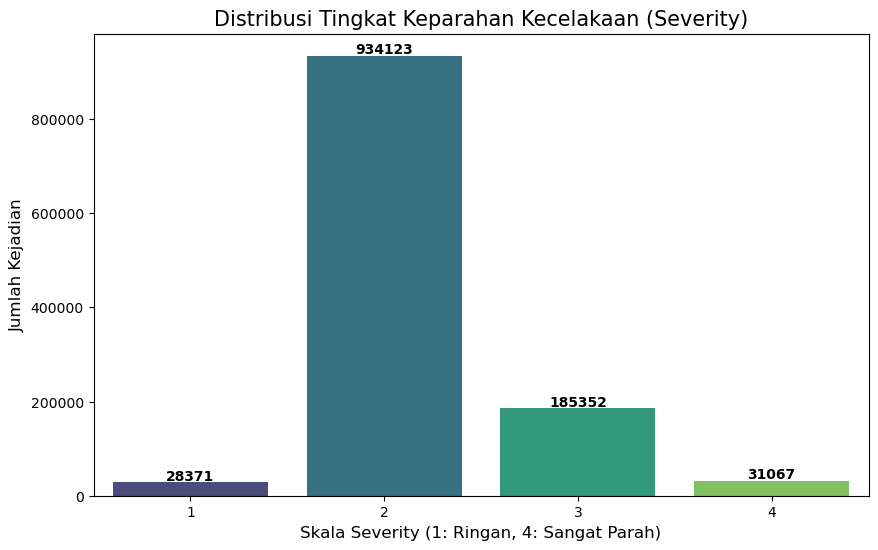

In [3]:
severity_counts = df['Severity'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='viridis')

plt.title('Distribusi Tingkat Keparahan Kecelakaan (Severity)', fontsize=15)
plt.xlabel('Skala Severity (1: Ringan, 4: Sangat Parah)', fontsize=12)
plt.ylabel('Jumlah Kejadian', fontsize=12)

for i, v in enumerate(severity_counts.values):
    plt.text(i, v + 5000, str(v), ha='center', fontweight='bold')

# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,1.178913e+06,1.178913e+06,1.178913e+06,708669.000000,708669.000000,1.178913e+06,1.147949e+06,1.138750e+06,1.145679e+06,1.152998e+06,1.148557e+06,1.143152e+06,1.116511e+06
mean,2.185862e+00,3.623964e+01,-9.548162e+01,36.396725,-97.404569,4.492280e-01,5.981137e+01,5.862050e+01,6.608177e+01,2.935166e+01,9.017523e+00,7.136620e+00,6.017451e-03
std,5.021481e-01,5.021891e+00,1.763442e+01,5.180773,18.517515,1.739455e+00,1.770719e+01,1.959923e+01,2.318382e+01,1.075922e+00,2.646711e+00,5.626493e+00,5.267433e-02
min,1.000000e+00,2.456309e+01,-1.244975e+02,24.574326,-124.497470,0.000000e+00,-8.900000e+01,-8.900000e+01,2.000000e+00,1.937000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.350028e+01,-1.174997e+02,33.699050,-118.104644,0.000000e+00,4.800000e+01,4.600000e+01,5.000000e+01,2.915000e+01,1.000000e+01,3.000000e+00,0.000000e+00
50%,2.000000e+00,3.580810e+01,-8.815047e+01,36.232960,-93.017730,0.000000e+00,6.100000e+01,6.100000e+01,7.000000e+01,2.966000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,3.998234e+01,-8.040440e+01,40.092670,-80.318508,2.450000e-01,7.300000e+01,7.300000e+01,8.600000e+01,2.995000e+01,1.000000e+01,1.000000e+01,0.000000e+00
max,4.000000e+00,4.899990e+01,-6.748413e+01,48.998901,-67.484130,4.417500e+02,2.030000e+02,1.890000e+02,1.000000e+02,5.804000e+01,1.200000e+02,9.840000e+02,2.400000e+01


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1178913 non-null  object 
 1   Source                 1178913 non-null  object 
 2   Severity               1178913 non-null  int64  
 3   Start_Time             1178913 non-null  object 
 4   End_Time               1178913 non-null  object 
 5   Start_Lat              1178913 non-null  float64
 6   Start_Lng              1178913 non-null  float64
 7   End_Lat                708669 non-null   float64
 8   End_Lng                708669 non-null   float64
 9   Distance(mi)           1178913 non-null  float64
 10  Description            1178912 non-null  object 
 11  Street                 1178476 non-null  object 
 12  City                   1178863 non-null  object 
 13  County                 1178913 non-null  object 
 14  State             

## Missing Value

In [9]:
# Mencari jumlah missing value tiap kolom
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  470244
End_Lng                  470244
Distance(mi)                  0
Description                   1
Street                      437
City                         50
County                        0
State                         0
Zipcode                     358
Country                       0
Timezone                   1343
Airport_Code               3084
Weather_Timestamp         23759
Temperature(F)            30964
Wind_Chill(F)             40163
Humidity(%)               33234
Pressure(in)              25915
Visibility(mi)            30356
Wind_Direction            35789
Wind_Speed(mph)           35761
Precipitation(in)         62402
Weather_Condition         29974
Amenity                       0
Bump                          0
Crossing

<Axes: >

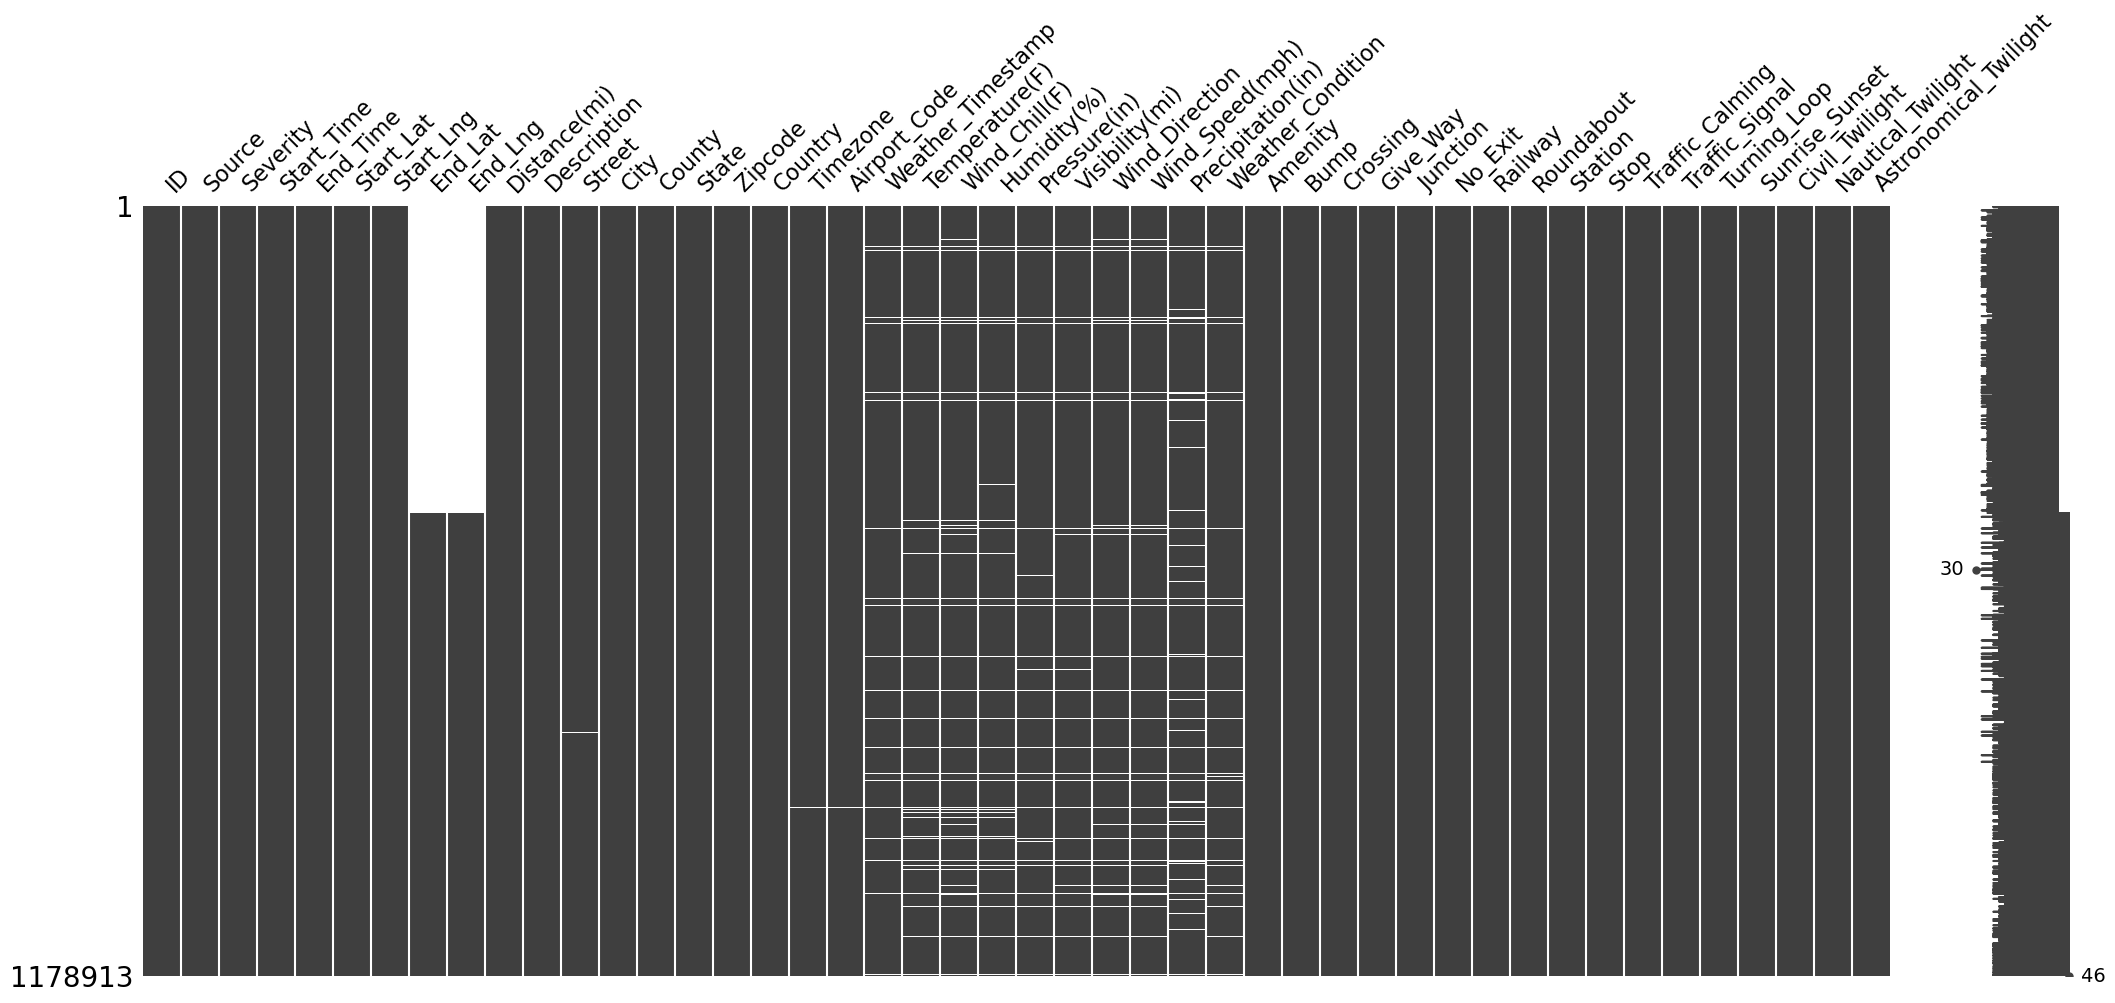

In [10]:
import missingno as msno
msno.matrix(df)

## Nilai Unik Tiap Kolom

In [11]:
unique_counts = df.nunique().sort_values(ascending=False)

unique_df = unique_counts.reset_index()
unique_df.columns = ['Nama Kolom', 'Jumlah Nilai Unik']
print("Jumlah Nilai Unik per Kolom (Urutan Terbanyak):")
print(unique_df)

Jumlah Nilai Unik per Kolom (Urutan Terbanyak):
               Nama Kolom  Jumlah Nilai Unik
0                      ID            1178913
1                End_Time             980254
2              Start_Time             875621
3             Description             682501
4               Start_Lng             541266
5               Start_Lat             532226
6                 End_Lng             322808
7                 End_Lat             318883
8                 Zipcode             192444
9       Weather_Timestamp             145004
10                 Street             115735
11           Distance(mi)              10408
12                   City               9541
13           Airport_Code               1852
14                 County               1565
15           Pressure(in)                965
16      Precipitation(in)                175
17          Wind_Chill(F)                169
18         Temperature(F)                154
19            Humidity(%)                 99
20     

## Kesimpulan Overview

- Kolom End_Lat dan End_Lng punya jumlah missing value yang sama. Apakah missingnya di baris yang sama?
- Kolom Sunrise_Sunset - Astronomical_Twilight punya jumlah missing value yang sama. Apakah missingnya di baris yang sama? Kolom ini berisi tentang apa? Kenapa kok jumlah missingnya bisa sama?
- Kolom Pressure - Wind Speed (kolom numerikal) ada missing value
- Kolom Turning_Loop, Country nilainya hanya 1
- Kolom Weather_Condition dan Wind_Direction (kategorikal) mengandung terlalu banyak kategori
- Kolom Temperature dan Wind_Chill satuannya sama, coba di cek
- **Jangan lupa impute missing value setelah tau polanya!**

# Hasil Explore Based On Overview

## Korelasi Kolom End_Latitude dan End_Longitude

In [12]:
# Cek kolom End_Lat dan Start_Lat
df['Lat_Diff'] = abs(df['End_Lat'] - df['Start_Lat'])

correlation = df['Start_Lat'].corr(df['End_Lat'])
same_exact = (df['Start_Lat'] == df['End_Lat']).mean() * 100
print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999995


In [13]:
# Cek kolom End_Lat dan Start_Lat
df['Lng_Diff'] = abs(df['End_Lng'] - df['Start_Lng'])

correlation = df['Start_Lng'].corr(df['End_Lng'])

same_exact = (df['Start_Lng'] == df['End_Lng']).mean() * 100

print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999999


Kolom End_Lat dan End_Lng boleh di **drop** karena nilainya mirip Start_Lat dan End_Lat

## 4 Kolom Terakhir

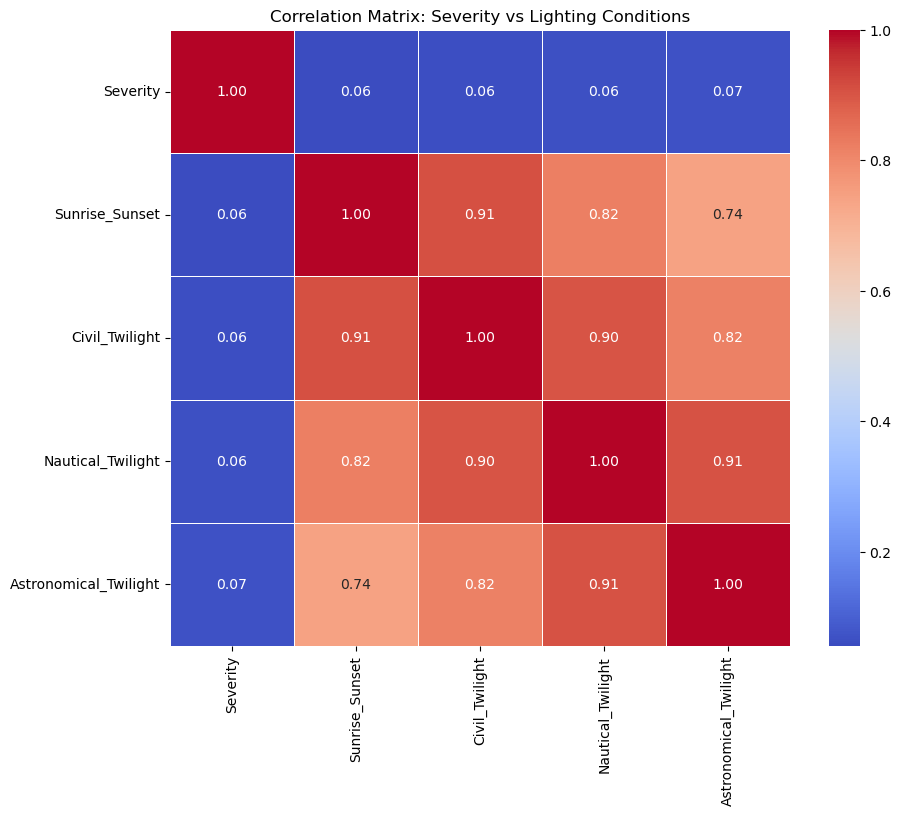

In [14]:
cols_to_analyze = ['Severity', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
df_corr = df[cols_to_analyze].copy()

for col in cols_to_analyze[1:]:
    df_corr[col] = df_corr[col].map({'Day': 1, 'Night': 0})

correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Severity vs Lighting Conditions')
plt.show()

Korelasi terbesar dimiliki oleh kolom Astronomical_Twilight. 
**Drop kolom lainnya**

In [15]:
df[['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']].head()

,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,Night,Night,Night,Day
1,Night,Night,Night,Night
2,Night,Night,Night,Night
3,Night,Night,Night,Night
4,Night,Night,Night,Night


## Korelasi Pearson antara Temperature dan Wind Chill

Korelasi Pearson antara Temperature dan Wind Chill: 0.9931


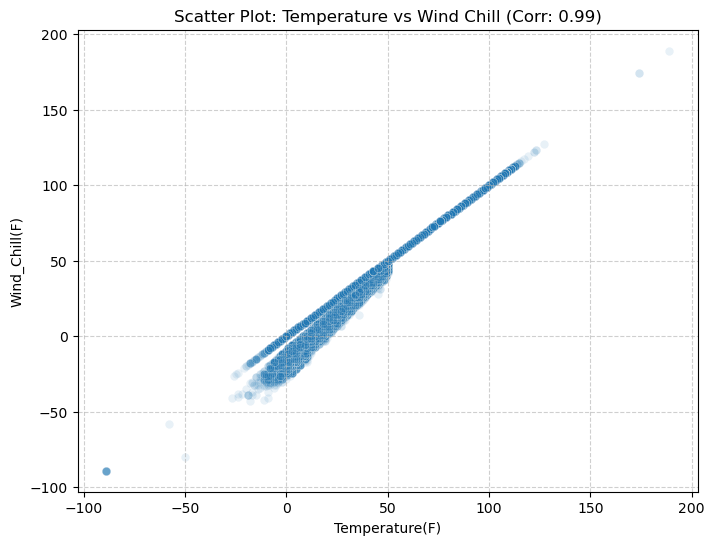

In [16]:
temp_wind_data = df[['Temperature(F)', 'Wind_Chill(F)']].dropna()

correlation = temp_wind_data['Temperature(F)'].corr(temp_wind_data['Wind_Chill(F)'])

print(f"Korelasi Pearson antara Temperature dan Wind Chill: {correlation:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature(F)', y='Wind_Chill(F)', data=temp_wind_data, alpha=0.1) # alpha=0.1 karena ada 500rb baris
plt.title(f'Scatter Plot: Temperature vs Wind Chill (Corr: {correlation:.2f})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Membuat Kolom Duration

In [13]:
cols_to_fix = ['Start_Time', 'End_Time']

for col in cols_to_fix:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[cols_to_fix].dtypes)
df[cols_to_fix].head()

df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

Start_Time    datetime64[ns]
End_Time      datetime64[ns]
dtype: object


## Keputusan

- Drop kolom End_Lat, Start_Lat, End_Lng, Start_Lng, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Wind_Chill, ID, Description, Street, Zipcode, Airport_Code, Weather_Timestamp, Country, Turning_Loop, Source

# To Do List
**Setelah melihat missing value, tipe data, nilai unik, dan nama dari setiap kolom, ada beberapa to do yang harus dikerjakan:**
- Membuang kolom yang tidak penting v
- Banyak outlier ga masuk akal. Cari data trus yg dibuat jadi NaN v
- Mengubah variabel time-time jadi datetype v
- Bikin kolom hour, day, month v
- Simplify kategori kolom `Wind Direction` v
- Simplify kategori kolom `Weather_Condition` v
- Impute `Weather_Condition` based on angka numerikal v
- Impute kolom `Temperature(F)`, `Humidity(%)`, `Pressure(in)` `Visibility(mi)`, `Precipitation(in)` dan `Wind_Speed(mph)` (kolom numerikal) berdasarkan `Weather_Condition` v
- Impute kolom City based on County v 
- Impute Astronomical_Twilight based on Hour, Date, + State v
- Impute Wind_Direction based on Jam + City v
- Impute End_Time based on Duration v
- Impute Weather Condition 'other'
- Memperbaiki kolom Distance

**EDA**
- Buat Geoplot dari kolom `State`

**Feature Engineering**
- Membuat kolom road_features 
- Membuat kolom Duration v


# Visualisasi Data Sebelum Cleaning

## Persebaran Data

### Data Numerikal

C:\Users\claire\AppData\Local\Temp\ipykernel_6452\1702321098.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)
C:\Users\claire\AppData\Local\Temp\ipykernel_6452\1702321098.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)
C:\Users\claire\AppData\Local\Temp\ipykernel_6452\1702321098.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)
C:\User

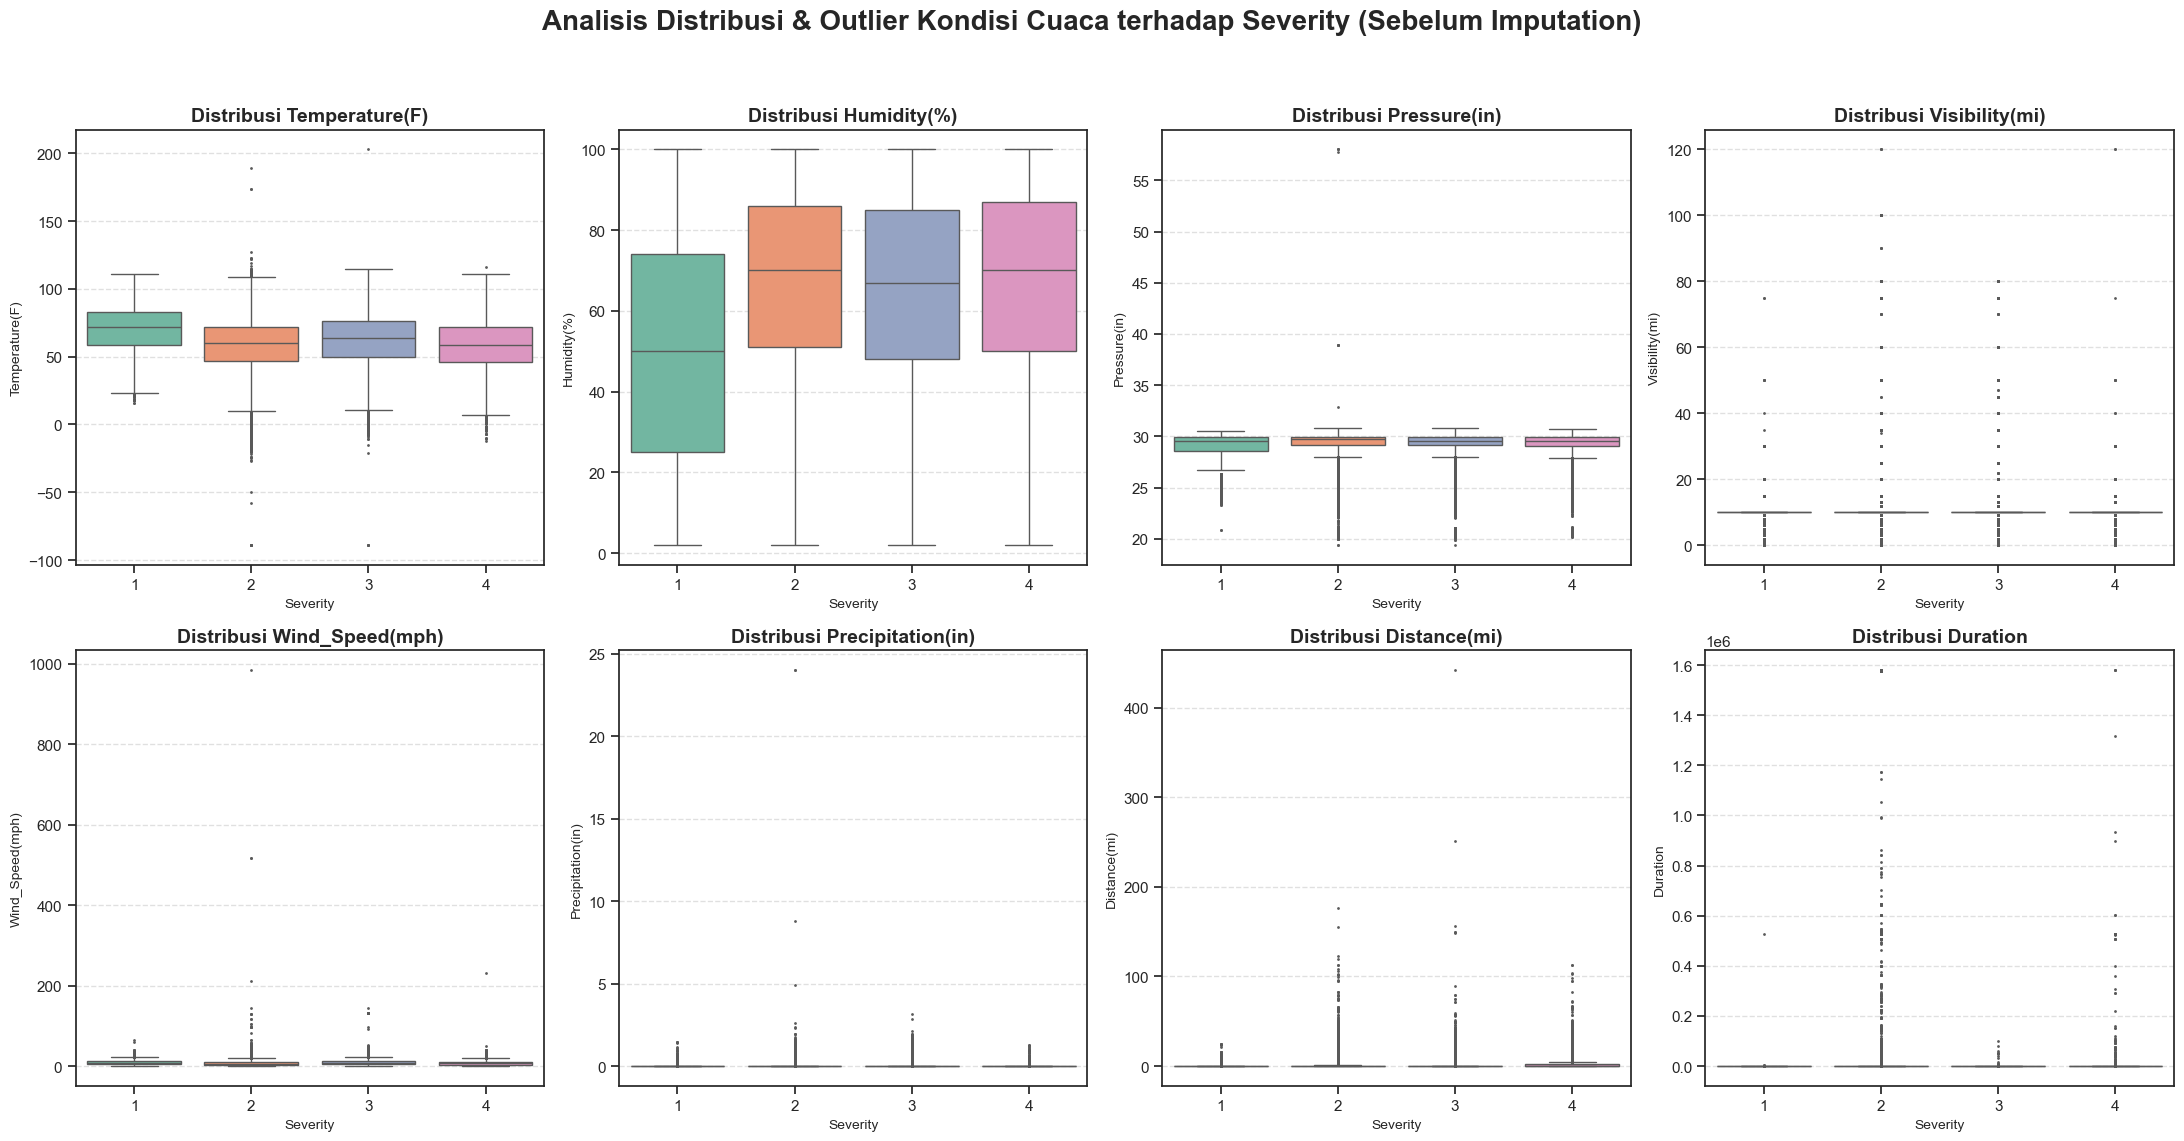

<Figure size 640x480 with 0 Axes>

In [19]:
num_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 
    'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)', 'Duration'
]

sns.set_theme(style="ticks")

# Membuat grid 2 baris x 4 kolom untuk total 8 plot
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 12))
fig.suptitle('Analisis Distribusi & Outlier Kondisi Cuaca terhadap Severity (Sebelum Imputation)', 
             fontsize=20, fontweight='bold', y=0.98)

# Iterasi melalui 8 kolom
for i, col in enumerate(num_cols):
    # Logika pembagian untuk grid 2x4
    row = i // 4  # Menggunakan pembagi 4 karena ada 4 kolom per baris
    col_idx = i % 4
    
    ax = axes[row, col_idx]
    
    # Membuat boxplot
    sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)

    ax.set_title(f'Distribusi {col}', fontsize=14, fontweight='semibold')
    ax.set_xlabel('Severity', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Menyesuaikan tata letak agar tidak tumpang tindih
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

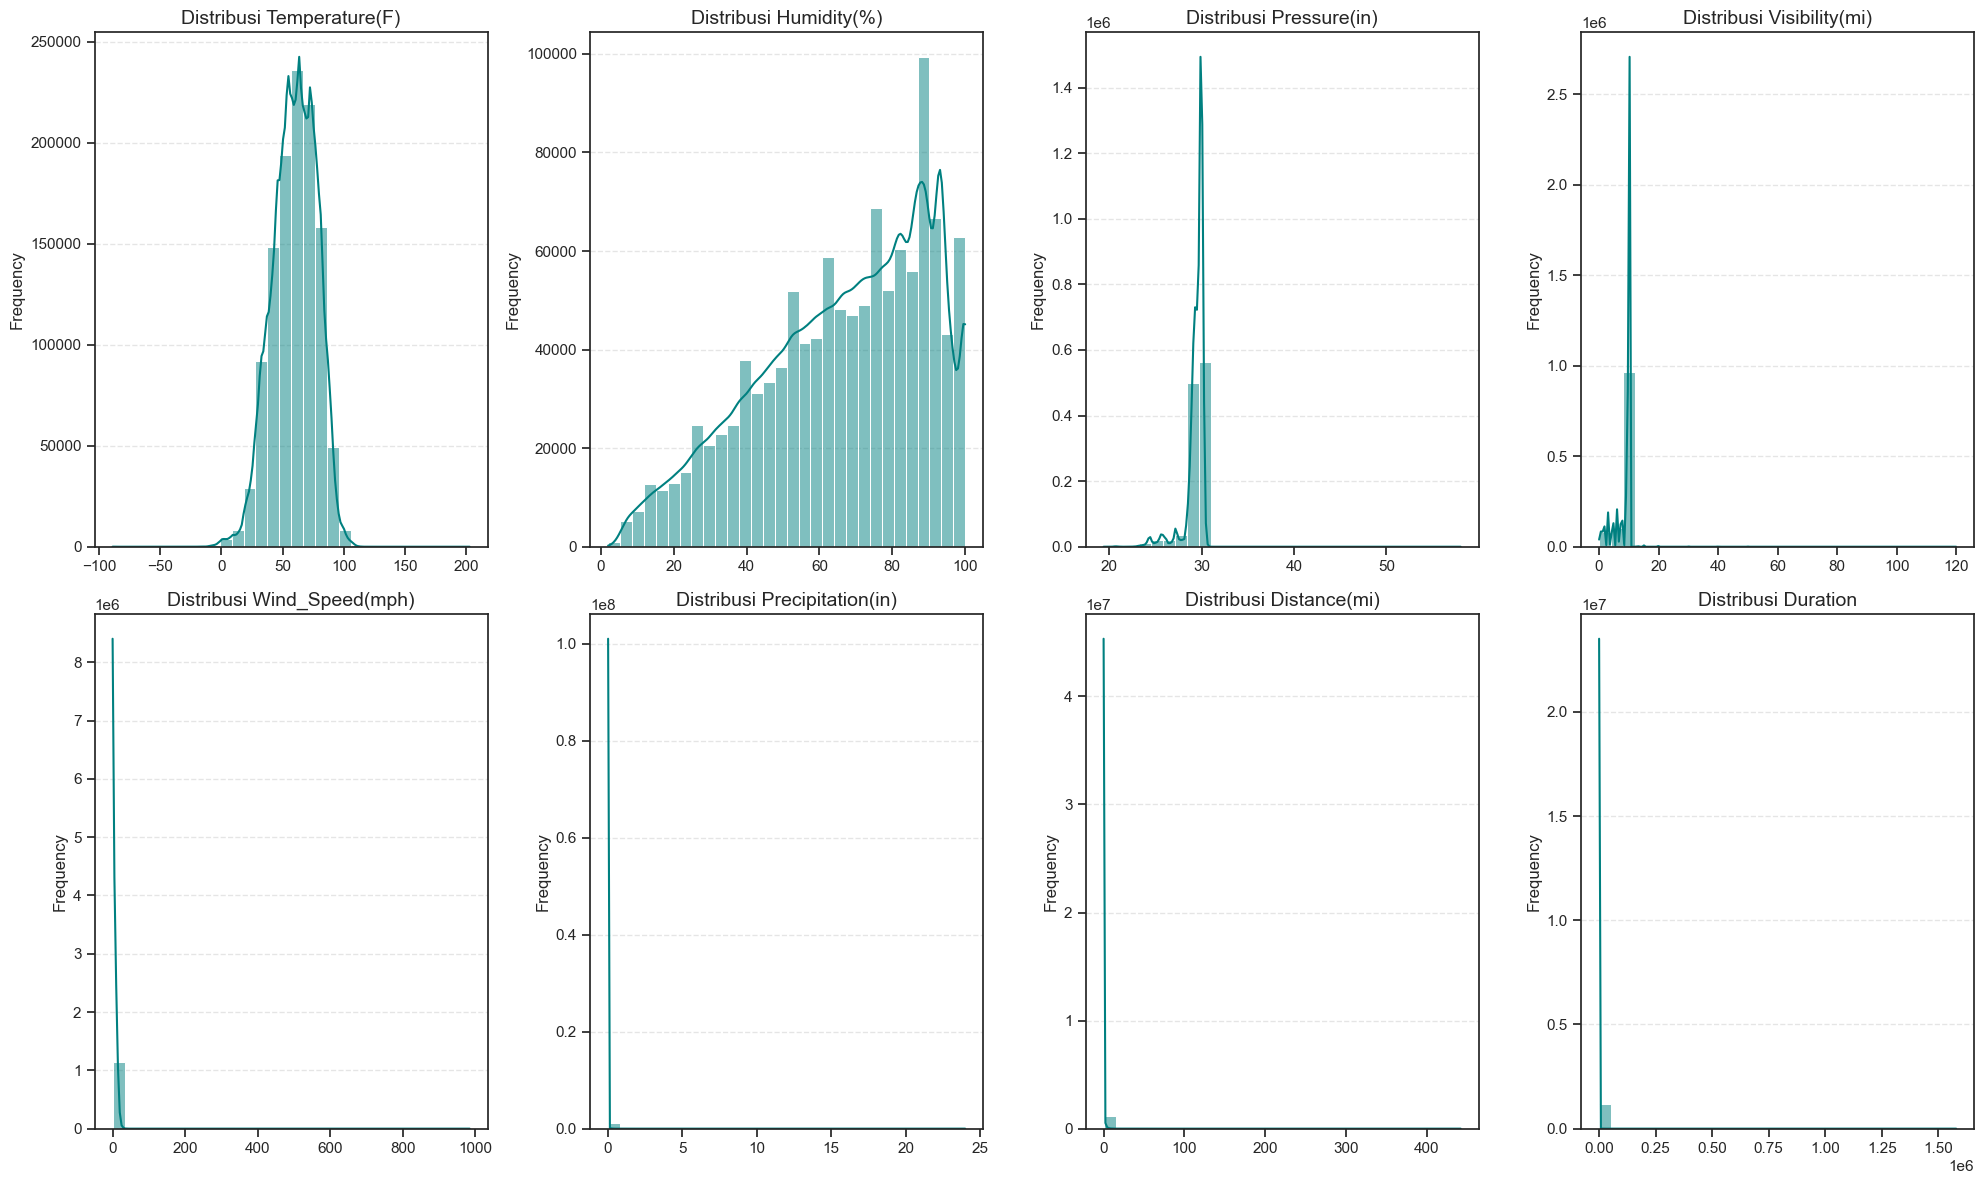

In [20]:
n_cols = 4
n_rows = 2

plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot histogram dengan kurva KDE
    sns.histplot(df[col], kde=True, color="teal", bins=30)
    
    plt.title(f"Distribusi {col}", fontsize=14)
    plt.xlabel("")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Data Kategorikal

#### Data Cuaca

In [3]:
sebaran_angka = df['Weather_Condition'].value_counts().sort_values(ascending=False)
print("Jumlah data per kategori:")
print(sebaran_angka)


Jumlah data per kategori:
Weather_Condition
Fair                         525322
Cloudy                       194891
Mostly Cloudy                150395
Partly Cloudy                 97000
Light Rain                    62493
                              ...  
Mist / Windy                      1
Sleet / Windy                     1
Sand / Dust Whirls Nearby         1
Thunder and Hail                  1
Drifting Snow                     1
Name: count, Length: 84, dtype: int64


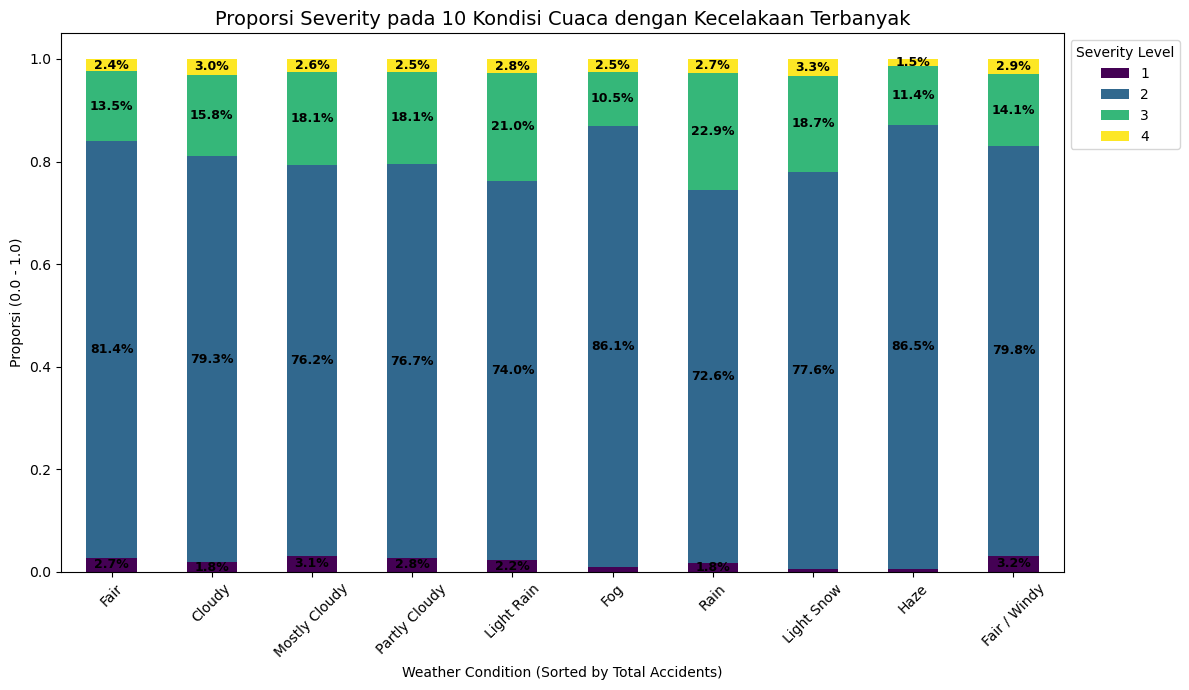

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil urutan kondisi cuaca berdasarkan jumlah kecelakaan terbanyak
# .index di sini sudah otomatis terurut dari yang terbanyak
top_weather_index = df['Weather_Condition'].value_counts().nlargest(10).index

# 2. Filter data
df_subset = df[df['Weather_Condition'].isin(top_weather_index)]

# 3. Buat crosstab
cross_tab = pd.crosstab(df_subset['Weather_Condition'], df_subset['Severity'], normalize='index')

# 4. KRUSIAL: Urutkan ulang (reindex) cross_tab sesuai dengan urutan top_weather_index
cross_tab = cross_tab.reindex(top_weather_index)

# 5. Plotting (Proporsi tetap 0-1 atau bisa dikali 100 jika mau)
ax = cross_tab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

# 6. Tambahkan label persentase
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0.01:
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='black', 
                fontsize=9,
                fontweight='bold')

plt.title("Proporsi Severity pada 10 Kondisi Cuaca dengan Kecelakaan Terbanyak", fontsize=14)
plt.ylabel("Proporsi (0.0 - 1.0)")
plt.xlabel("Weather Condition (Sorted by Total Accidents)")
plt.legend(title="Severity Level", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\claire\AppData\Local\Temp\ipykernel_11164\563947389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_20_weather.index, y=top_20_weather.values, palette='viridis')


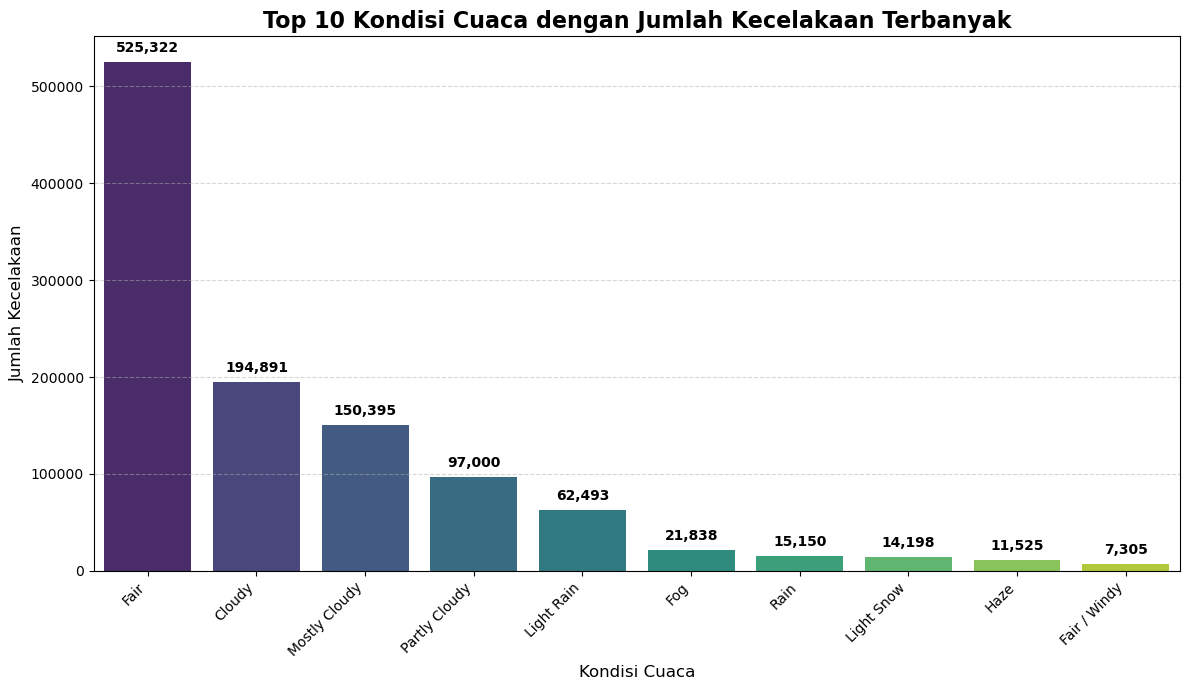

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menghitung jumlah kecelakaan per kondisi cuaca dan mengambil 20 teratas
top_20_weather = df['Weather_Condition'].value_counts().nlargest(10)

# 2. Membuat plot
plt.figure(figsize=(12, 7))
# Menggunakan barplot dari seaborn
ax = sns.barplot(x=top_20_weather.index, y=top_20_weather.values, palette='viridis')

# 3. Menambahkan label jumlah (angka) di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=10,
                fontweight='bold')

# 4. Estetika Grafik
plt.title("Top 10 Kondisi Cuaca dengan Jumlah Kecelakaan Terbanyak", fontsize=16, fontweight='bold')
plt.xlabel("Kondisi Cuaca", fontsize=12)
plt.ylabel("Jumlah Kecelakaan", fontsize=12)
plt.xticks(rotation=45, ha='right') # Memiringkan label agar tidak bertabrakan
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Memberikan ruang agar label di sumbu X tidak terpotong
plt.tight_layout()
plt.show()

## Jumlah Baris dengan Nilai yang Tidak Wajar

### Persentile 99%

In [21]:
print(f"Batas 99% data Temperature: {df['Temperature(F)'].quantile(0.99):.2f} F")
print(f"Batas 99% data Humidity: {df['Humidity(%)'].quantile(0.99):.2f} %")
print(f"Batas 99% data Pressure: {df['Pressure(in)'].quantile(0.99):.2f} inci")
print(f"Batas 99% data Visibility: {df['Visibility(mi)'].quantile(0.99):.2f} mil")
print(f"Batas 99% data Wind_Speed: {df['Wind_Speed(mph)'].quantile(0.99):.2f} mph")
print(f"Batas 99% data Precipitation: {df['Precipitation(in)'].quantile(0.99):.2f} inci")
print(f"Batas 99% data Distance: {df['Distance(mi)'].quantile(0.99):.2f} mil")
print(f"Batas 99% data Duration: {df['Duration'].quantile(0.99):.2f} min")

Batas 99% data Temperature: 95.00 F
Batas 99% data Humidity: 100.00 %
Batas 99% data Pressure: 30.35 inci
Batas 99% data Visibility: 10.00 mil
Batas 99% data Wind_Speed: 23.00 mph
Batas 99% data Precipitation: 0.15 inci
Batas 99% data Distance: 6.17 mil
Batas 99% data Duration: 920.50 min


### Persentile 99.9%

In [22]:
print(f"Batas 99,9% data Temperature: {df['Temperature(F)'].quantile(0.999):.2f} F")
print(f"Batas 99,9% data Humidity: {df['Humidity(%)'].quantile(0.999):.2f} %")
print(f"Batas 99,9% data Pressure: {df['Pressure(in)'].quantile(0.999):.2f} inci")
print(f"Batas 99,9% data Visibility: {df['Visibility(mi)'].quantile(0.999):.2f} mil")
print(f"Batas 99,9% data Wind_Speed: {df['Wind_Speed(mph)'].quantile(0.999):.2f} mph")
print(f"Batas 99,9% data Precipitation: {df['Precipitation(in)'].quantile(0.999):.2f} inci")
print(f"Batas 99,9% data Distance: {df['Distance(mi)'].quantile(0.999):.2f} mil")
print(f"Batas 99,9% data Duration: {df['Duration'].quantile(0.999):.2f} menit")

Batas 99,9% data Temperature: 105.00 F
Batas 99,9% data Humidity: 100.00 %
Batas 99,9% data Pressure: 30.54 inci
Batas 99,9% data Visibility: 20.00 mil
Batas 99,9% data Wind_Speed: 31.00 mph
Batas 99,9% data Precipitation: 0.56 inci
Batas 99,9% data Distance: 19.18 mil
Batas 99,9% data Duration: 56385.66 menit


### Nilai di luar Rentang

In [23]:
# 1. Definisikan Threshold dalam Dictionary (Min, Max)
thresholds = {
    'Temperature(F)': (-42, 123),
    'Humidity(%)': (5, 100),
    'Pressure(in)': (22.1, 31.1),
    'Visibility(mi)': (0, 10),
    'Wind_Speed(mph)': (0, 23),
    'Precipitation(in)': (0, 2),
    'Distance(mi)' : (0, 300),
    'Duration' : (0, 3000) # 2 hari
}

results = []

# 2. Iterasi untuk mengecek per kolom
for col, (low, high) in thresholds.items():
    if col in df.columns:
        # Menghitung data yang di luar rentang DAN bukan NaN
        outliers_count = df[
            (df[col].notna()) & 
            ((df[col] < low) | (df[col] > high))
        ].shape[0]
        
        results.append({
            'Kolom': col,
            'Rentang Normal': f"{low} s/d {high}",
            'Jumlah Outlier': outliers_count
        })

# 3. Tampilkan dalam DataFrame agar rapi
df_outliers = pd.DataFrame(results)
print(df_outliers.to_markdown(index=False))

| Kolom             | Rentang Normal   |   Jumlah Outlier |
|:------------------|:-----------------|-----------------:|
| Temperature(F)    | -42 s/d 123      |               17 |
| Humidity(%)       | 5 s/d 100        |              267 |
| Pressure(in)      | 22.1 s/d 31.1    |              610 |
| Visibility(mi)    | 0 s/d 10         |             3009 |
| Wind_Speed(mph)   | 0 s/d 23         |             8781 |
| Precipitation(in) | 0 s/d 2          |               10 |
| Distance(mi)      | 0 s/d 300        |                1 |
| Duration          | 0 s/d 3000       |             2614 |


## Korelasi Pearson antar Fitur

In [24]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
correlations = df.select_dtypes(include=[np.number]).corr()['Severity'].sort_values(ascending=False)
print("Korelasi Fitur terhadap Severity di Awal:")
print(correlations)

Korelasi Fitur terhadap Severity di Awal:
Severity             1.000000
End_Lng              0.140340
Start_Lng            0.122403
End_Lat              0.101578
Distance(mi)         0.100393
Lng_Diff             0.084135
Lat_Diff             0.075969
Start_Lat            0.074482
Wind_Speed(mph)      0.046215
Junction             0.031613
Precipitation(in)    0.028273
Humidity(%)          0.022308
Temperature(F)       0.010252
Wind_Chill(F)        0.004667
Traffic_Calming      0.001406
Duration            -0.000418
Bump                -0.000674
Roundabout          -0.001639
Give_Way            -0.005675
No_Exit             -0.007931
Railway             -0.012659
Pressure(in)        -0.013124
Visibility(mi)      -0.017271
Amenity             -0.020518
Station             -0.034228
Stop                -0.036607
Crossing            -0.111245
Traffic_Signal      -0.117975
Turning_Loop              NaN
Name: Severity, dtype: float64


## Persebaran Kolom Cuaca

In [11]:
df.Weather_Condition.value_counts()

Weather_Condition
Fair                         525322
Cloudy                       194891
Mostly Cloudy                150395
Partly Cloudy                 97000
Light Rain                    62493
                              ...  
Mist / Windy                      1
Sleet / Windy                     1
Sand / Dust Whirls Nearby         1
Thunder and Hail                  1
Drifting Snow                     1
Name: count, Length: 84, dtype: int64

# Data Cleaning

## Membuang Kolom Redundant dan Useless

In [25]:
# Hapus kolom tidak penting
cols_to_drop = [
    'End_Lat', 'End_Lng', 'Start_Lat', 'Start_Lng', 'Sunrise_Sunset', 'Civil_Twilight', 
    'Nautical_Twilight', 'Wind_Chill(F)', 'ID', 'Description', 
    'Street', 'Zipcode', 'Airport_Code', 'Weather_Timestamp', 
    'Country', 'Turning_Loop', 'Source', 'Lat_Diff', 'Lng_Diff', 'Timezone'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

Kolom yang di drop adalah kolom-kolom yang **redundant dan tidak berguna untuk model**

**Melalui visualisasi tersebut, dapat dilihat bahwa:**
- Semua kolom memiliki outlier yang tidak wajar, kecuali kolom Humidity. Kita bisa mempertimbangkan untuk impute dengam metode groupby City and Hour dengan median

## Mengubah Nilai Aneh jadi NaN

Data diubah jadi NaN agar data bisa diimputasi dengan nilai yang sesuai kota dan waktu kejadiannya

Kita gatau nilainya aneh karena nilainya maksimal atau sensornya yang rusak

In [26]:
df[num_cols].isnull().sum()

Temperature(F)       30964
Humidity(%)          33234
Pressure(in)         25915
Visibility(mi)       30356
Wind_Speed(mph)      35761
Precipitation(in)    62402
Distance(mi)             0
Duration             17315
dtype: int64

In [27]:
df.loc[(df['Temperature(F)'] < -42) | (df['Temperature(F)'] > 123), 'Temperature(F)'] = np.nan
df.loc[(df['Humidity(%)'] < 5) | (df['Humidity(%)'] > 100), 'Humidity(%)'] = np.nan
df.loc[(df['Pressure(in)'] < 22.1) | (df['Pressure(in)'] > 31.3), 'Pressure(in)'] = np.nan
df.loc[(df['Visibility(mi)'] < 0) | (df['Visibility(mi)'] > 10), 'Visibility(mi)'] = np.nan
df.loc[(df['Wind_Speed(mph)'] < 0) | (df['Wind_Speed(mph)'] > 23), 'Wind_Speed(mph)'] = np.nan
df.loc[(df['Precipitation(in)'] < 0) | (df['Precipitation(in)'] > 2), 'Precipitation(in)'] = np.nan
df.loc[(df['Distance(mi)'] < 0) | (df['Distance(mi)'] > 300), 'Wind_Speed(mph)'] = np.nan
df.loc[(df['Duration'] < 0) | (df['Duration'] > 3000), 'Precipitation(in)'] = np.nan

In [28]:
df[num_cols].isnull().sum()

Temperature(F)       30981
Humidity(%)          33501
Pressure(in)         26525
Visibility(mi)       33365
Wind_Speed(mph)      44543
Precipitation(in)    64982
Distance(mi)             0
Duration             17315
dtype: int64

## Buat Kolom Hour, Day, Month

In [3]:
cols_to_fix = ['Start_Time', 'End_Time']

for col in cols_to_fix:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [4]:
df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['Day'] = df['Start_Time'].dt.dayofweek

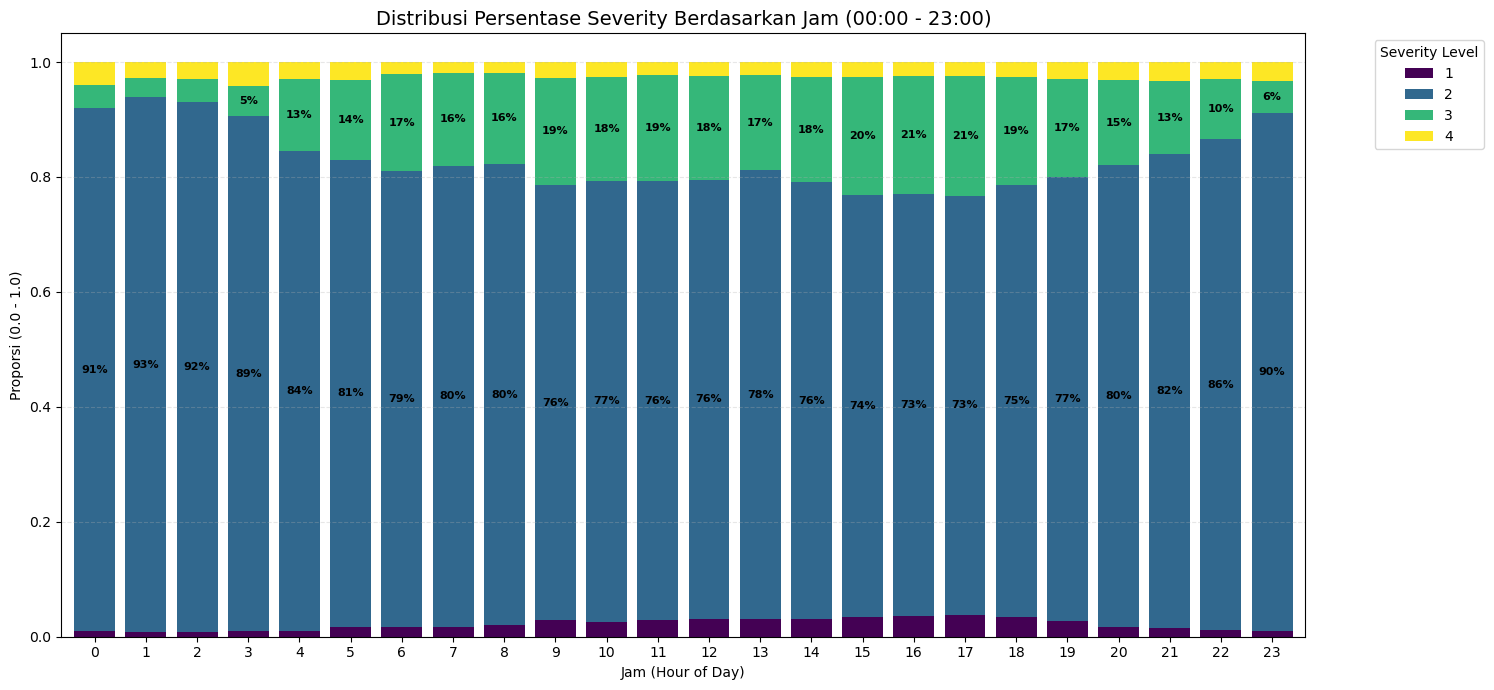

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pastikan data terurut berdasarkan jam (0-23) agar grafik tidak melompat-lompat
df_sorted = df.sort_values('Hour')

# 2. Buat crosstab antara 'Hour' dan 'Severity'
# Kita tidak perlu mengambil nlargest(10) jika ingin melihat tren waktu yang utuh
cross_tab = pd.crosstab(df_sorted['Hour'], df_sorted['Severity'], normalize='index')

# 3. Plotting
ax = cross_tab.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis', width=0.8)

# 4. Menambahkan label persentase di dalam batang (opsional)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    # Hanya tampilkan teks jika proporsi cukup besar agar tidak berantakan
    if height > 0.05: 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.0%}', # Menggunakan 0 desimal agar lebih bersih untuk 24 jam
                horizontalalignment='center', 
                verticalalignment='center',
                color='black', 
                fontsize=8,
                fontweight='bold')

# 5. Estetika Grafik
plt.title("Distribusi Persentase Severity Berdasarkan Jam (00:00 - 23:00)", fontsize=14)
plt.ylabel("Proporsi (0.0 - 1.0)")
plt.xlabel("Jam (Hour of Day)")
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0) # Jam lebih enak dibaca jika horizontal
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Simplifikasi Kolom Wind_Direction

In [30]:
df.loc[df['Wind_Direction']=='Calm','Wind_Direction'] = 'CALM'
df.loc[(df['Wind_Direction']=='West')|(df['Wind_Direction']=='WSW')|(df['Wind_Direction']=='WNW'),'Wind_Direction'] = 'W'
df.loc[(df['Wind_Direction']=='South')|(df['Wind_Direction']=='SSW')|(df['Wind_Direction']=='SSE'),'Wind_Direction'] = 'S'
df.loc[(df['Wind_Direction']=='North')|(df['Wind_Direction']=='NNW')|(df['Wind_Direction']=='NNE'),'Wind_Direction'] = 'N'
df.loc[(df['Wind_Direction']=='East')|(df['Wind_Direction']=='ESE')|(df['Wind_Direction']=='ENE'),'Wind_Direction'] = 'E'
df.loc[df['Wind_Direction']=='Variable','Wind_Direction'] = 'VAR'

print("Wind Direction after simplification: ", df['Wind_Direction'].unique())
print('Jumlah nilai unik Wind Direction:', df.Wind_Direction.nunique())

Wind Direction after simplification:  ['S' 'CALM' 'E' 'SE' 'W' 'NW' 'N' 'SW' 'VAR' nan 'NE']
Jumlah nilai unik Wind Direction: 10


## Simplifikasi Kolom Weather_Condition

In [31]:
# Cari tau kategori di Weather_Condition
df.Weather_Condition.unique()

array(['Fair', 'Mostly Cloudy', 'Cloudy', 'Light Rain',
       'Light Rain / Windy', 'Light Snow', 'Partly Cloudy', 'Rain',
       'Haze', nan, 'Wintry Mix', 'Fog', 'Light Drizzle', 'Heavy Rain',
       'T-Storm', 'Fair / Windy', 'Drizzle and Fog',
       'Partly Cloudy / Windy', 'Light Rain with Thunder', 'Rain / Windy',
       'Heavy T-Storm', 'Cloudy / Windy', 'Heavy Rain / Windy',
       'Light Freezing Rain', 'Mist', 'Snow', 'Light Freezing Drizzle',
       'Drizzle', 'N/A Precipitation', 'Mostly Cloudy / Windy',
       'Wintry Mix / Windy', 'Light Snow / Windy', 'Heavy Snow',
       'Patches of Fog', 'Showers in the Vicinity', 'Shallow Fog',
       'Thunder', 'Snow / Windy', 'Heavy Snow / Windy', 'T-Storm / Windy',
       'Fog / Windy', 'Haze / Windy', 'Heavy T-Storm / Windy',
       'Thunder in the Vicinity', 'Snow and Sleet / Windy',
       'Blowing Snow / Windy', 'Blowing Snow', 'Light Snow and Sleet',
       'Light Sleet', 'Smoke', 'Heavy Drizzle', 'Thunder / Windy',
       '

In [32]:
conditions = [
    # 1. HAIL & SLEET: Paling spesifik dan ekstrem
    df['Weather_Condition'].str.contains('hail|sleet', case=False, na=False),
    
    # 2. THUNDERSTORM: Badai dan petir
    df['Weather_Condition'].str.contains('thunder|t-storm|squalls', case=False, na=False),
    
    # 3. SNOW: Salju dan kondisi beku (Wintry Mix masuk sini)
    df['Weather_Condition'].str.contains('snow|wintry|freezing|blizzard', case=False, na=False),
    
    # 4. RAIN: Semua jenis hujan dan gerimis
    df['Weather_Condition'].str.contains('rain|drizzle|shower|precipitation', case=False, na=False),
    
    # 5. FOG: Kabut, asap, dan debu
    df['Weather_Condition'].str.contains('fog|haze|mist|smoke|dust|sand|patches', case=False, na=False),
    
    # 6. CLEAR/CLOUDY: Cerah atau mendung tanpa presipitasi
    df['Weather_Condition'].str.contains('fair|cloudy|clear|overcast', case=False, na=False)
]

choices = ['hail', 'thunderstorm', 'snow', 'rain', 'fog', 'clear']

df['Weather_Condition'] = np.select(conditions, choices, default='other')

print("Distribusi Hasil Simplifikasi:")
print(df['Weather_Condition'].value_counts())

Distribusi Hasil Simplifikasi:
Weather_Condition
clear           985581
rain             92847
fog              40111
other            29974
snow             19747
thunderstorm     10558
hail                95
Name: count, dtype: int64


## Impute Kolom Cuaca 
Kolom numerical diimputasi menggunakan median per City dan Month. Jika menggunakan Weather_Condition, kemungkinan hasil imputasi akan error. Hal ini dikarenakan label cuaca itu subjektif dan terlalu luas, sedangkan lokasi dan waktu itu absolut.

Label Weather_Condition seperti "Fair" (Cerah) punya arti suhu yang sangat berbeda di tempat yang berbeda.
- Kasus A: Di Miami, Florida saat bulan Januari, cuaca "Fair" suhunya bisa 75°F.
- Kasus B: Di Minneapolis, Minnesota saat bulan Januari, cuaca "Fair" suhunya bisa -5°F.

In [33]:
weather_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

for col in weather_cols:
    df[col] = df[col].fillna(df.groupby(['City', 'Month'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby(['State', 'Month'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby('Month')[col].transform('median'))

df[weather_cols].isnull().sum()

Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Speed(mph)      0
Precipitation(in)    0
dtype: int64

## Impute Weather Condition
Weather Condition di impute berdasarkan persebaran geografis dan waktu (bulan) menggunakan nilai modus. Dengan menggunakan city dan month, kita berusaha menangkap pola cuaca yang terjadi di bulan dan kota tersebut


Jika imputasi dilakukan berdasarkan atribut cuaca (temperature, humidity, dll), akan berisiko bias karena terlalu banyak kolom yang dipertimbangkan untuk melakukan imputasi. Satu label cuaca bisa mewakili banyak kondisi. 

In [34]:
df.loc[df['Weather_Condition'] == 'other', 'Weather_Condition'] = np.nan

df.loc[(df['Weather_Condition'].isna()) & (df['Precipitation(in)'] > 0) & (df['Temperature(F)'] <= 32), 'Weather_Condition'] = 'snow'
df.loc[(df['Weather_Condition'].isna()) & (df['Precipitation(in)'] > 0) & (df['Temperature(F)'] > 32), 'Weather_Condition'] = 'rain'
df.loc[(df['Weather_Condition'].isna()) & (df['Visibility(mi)'] < 1), 'Weather_Condition'] = 'fog'

df['Weather_Condition'] = df['Weather_Condition'].fillna(
    df.groupby(['City', 'Month'])['Weather_Condition'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

df['Weather_Condition'] = df['Weather_Condition'].fillna(
    df.groupby(['State', 'Month'])['Weather_Condition'].transform(lambda x: x.mode()[0] if not x.mode().empty else "clear")
)

In [35]:
df.Weather_Condition.isnull().sum()

np.int64(0)

In [36]:
df.Weather_Condition.unique()

array(['clear', 'rain', 'snow', 'fog', 'thunderstorm', 'hail'],
      dtype=object)

## Impute City based on Modus di County

In [37]:
# Impute kolom City based on modus di County
df['City'] = df.groupby('County')['City'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown City")
)
df['City'] = df['City'].fillna("Unknown City")

## Impute Astronomical_Twilight

In [38]:
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

fallback_levels = [
    ['State', 'Month', 'Hour'],
    ['Month', 'Hour'],
    ['Hour']
]

for level in fallback_levels:
    df['Astronomical_Twilight'] = df['Astronomical_Twilight'].fillna(
        df.groupby(level)['Astronomical_Twilight'].transform(get_mode)
    )


In [39]:
df.Astronomical_Twilight.isnull().sum()

np.int64(0)

## Impute Wind_Direction

In [40]:
# Impute kolom Wind_Direction based on City dan Month
df['Wind_Direction'] = df['Wind_Direction'].fillna(
    df.groupby(['City', 'Month'])['Wind_Direction'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)

df['Wind_Direction'] = df['Wind_Direction'].fillna(
    df.groupby(['State', 'Month'])['Wind_Direction'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)

global_mode = df['Wind_Direction'].mode()[0]
df['Wind_Direction'] = df['Wind_Direction'].fillna(global_mode)

In [41]:
df.Wind_Direction.isnull().sum()

np.int64(0)

## Impute End Time

In [14]:
median_duration = df['Duration'].median()

df['Duration'] = df['Duration'].fillna(median_duration)

mask_missing_end = df['End_Time'].isnull()

df.loc[mask_missing_end, 'End_Time'] = df.loc[mask_missing_end, 'Start_Time'] + \
                                       pd.to_timedelta(df.loc[mask_missing_end, 'Duration'], unit='m')

print(f"Jumlah End_Time kosong setelah imputasi: {df['End_Time'].isnull().sum()}")

Jumlah End_Time kosong setelah imputasi: 0


## Capping Kolom Distance

In [43]:
print(f"Batas 99% data Distance: {df['Distance(mi)'].quantile(0.99):.2f} mil")

Batas 99% data Distance: 6.17 mil


In [44]:
outliers_100 = df[df['Distance(mi)'] > 6.17]
count_outliers = len(outliers_100)
print(f"Jumlah baris dengan Distance(mi) > 6.17: {count_outliers}")

Jumlah baris dengan Distance(mi) > 6.17: 11793


In [45]:
threshold = 300
df['Distance(mi)'] = df['Distance(mi)'].clip(upper=threshold)

## Capping Kolom Durasi

In [46]:
outliers_100 = df[df['Duration'] > 540]
count_outliers = len(outliers_100)
print(f"Jumlah baris dengan Duration > 540: {count_outliers}")

Jumlah baris dengan Duration > 540: 42928


In [47]:
threshold = 3000
df['Duration'] = df['Duration'].clip(upper=threshold)

## Membuat Road_Features

In [9]:
# Membuat kolom road_features
road_features = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal"
]

df["Road_Features"] = df[road_features].sum(axis=1)

# Visualisasi Data Setelah di Impute

## Persebaran 8 Kolom Numerikal

C:\Users\claire\AppData\Local\Temp\ipykernel_17040\2015151161.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)
C:\Users\claire\AppData\Local\Temp\ipykernel_17040\2015151161.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)
C:\Users\claire\AppData\Local\Temp\ipykernel_17040\2015151161.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)
C:\U

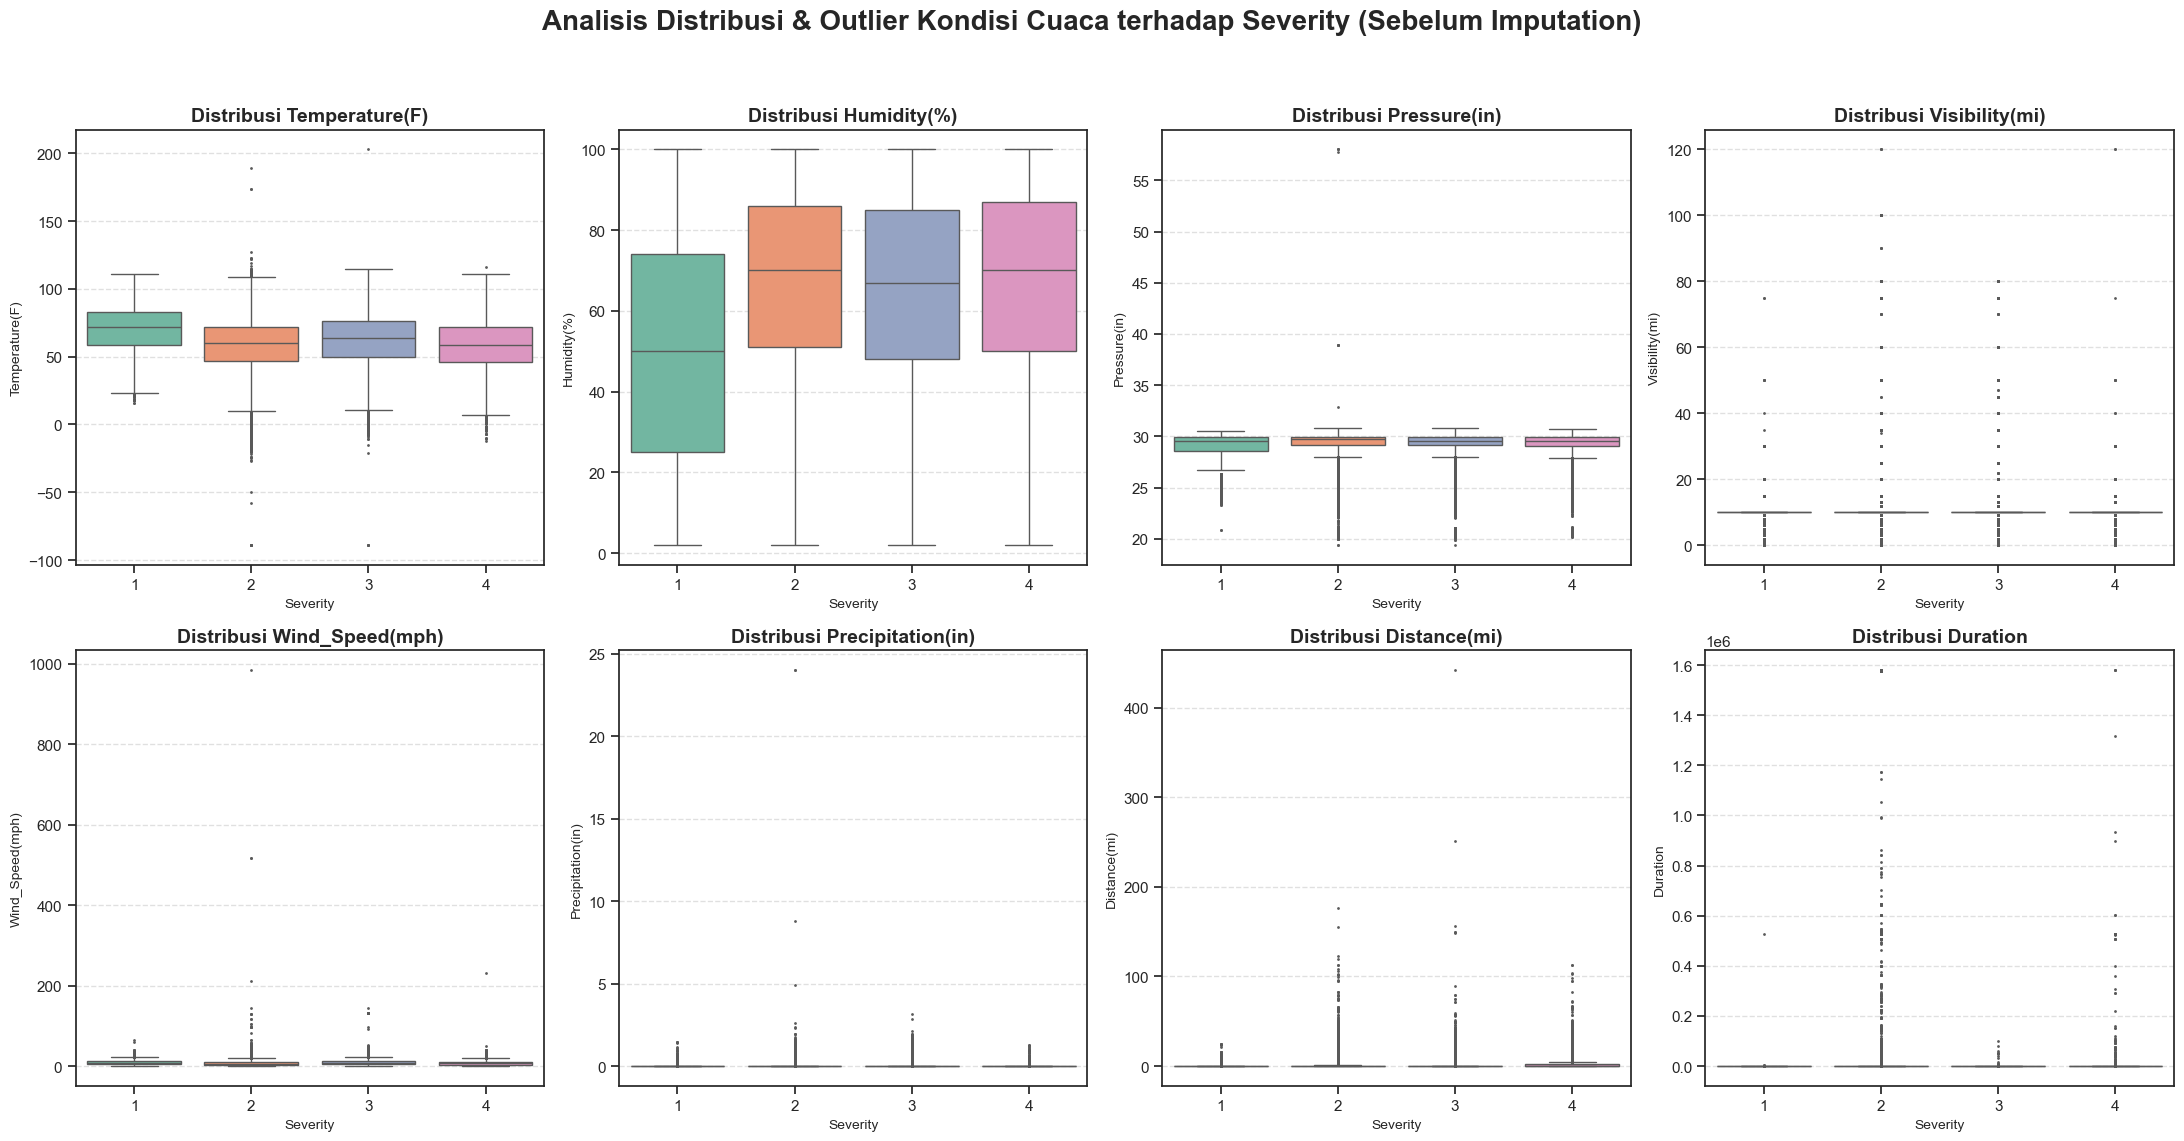

<Figure size 640x480 with 0 Axes>

In [15]:
num_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 
    'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)', 'Duration'
]
sns.set_theme(style="ticks")

# Membuat grid 2 baris x 4 kolom untuk total 8 plot
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 12))
fig.suptitle('Analisis Distribusi & Outlier Kondisi Cuaca terhadap Severity (Sebelum Imputation)', 
             fontsize=20, fontweight='bold', y=0.98)

# Iterasi melalui 8 kolom
for i, col in enumerate(num_cols):
    # Logika pembagian untuk grid 2x4
    row = i // 4  # Menggunakan pembagi 4 karena ada 4 kolom per baris
    col_idx = i % 4
    
    ax = axes[row, col_idx]
    
    # Membuat boxplot
    sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)

    ax.set_title(f'Distribusi {col}', fontsize=14, fontweight='semibold')
    ax.set_xlabel('Severity', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Menyesuaikan tata letak agar tidak tumpang tindih
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [50]:
df = df.drop(columns='Timezone', errors='ignore')

## Missing Value

In [51]:
df.isnull().sum()

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Duration                 0
Hour                     0
Month                    0
Day                      0
Road_Features            0
dtype: int64

In [52]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
correlations = df.select_dtypes(include=[np.number]).corr()['Severity'].sort_values(ascending=False)
print("Korelasi Fitur terhadap Severity di Akhir:")
print(correlations)

Korelasi Fitur terhadap Severity di Akhir:
Severity             1.000000
Distance(mi)         0.101791
Wind_Speed(mph)      0.047614
Precipitation(in)    0.037377
Junction             0.031613
Hour                 0.029040
Day                  0.024540
Humidity(%)          0.021584
Temperature(F)       0.011919
Traffic_Calming      0.001406
Bump                -0.000674
Roundabout          -0.001639
Give_Way            -0.005675
No_Exit             -0.007931
Pressure(in)        -0.008469
Railway             -0.012659
Amenity             -0.020518
Visibility(mi)      -0.022728
Station             -0.034228
Stop                -0.036607
Duration            -0.038815
Month               -0.095685
Crossing            -0.111245
Road_Features       -0.116210
Traffic_Signal      -0.117975
Name: Severity, dtype: float64


In [53]:
df.shape

(1178913, 33)

In [54]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Astronomical_Twilight',
       'Duration', 'Hour', 'Month', 'Day', 'Road_Features'],
      dtype='object')

## Persebaran dengan Histogram

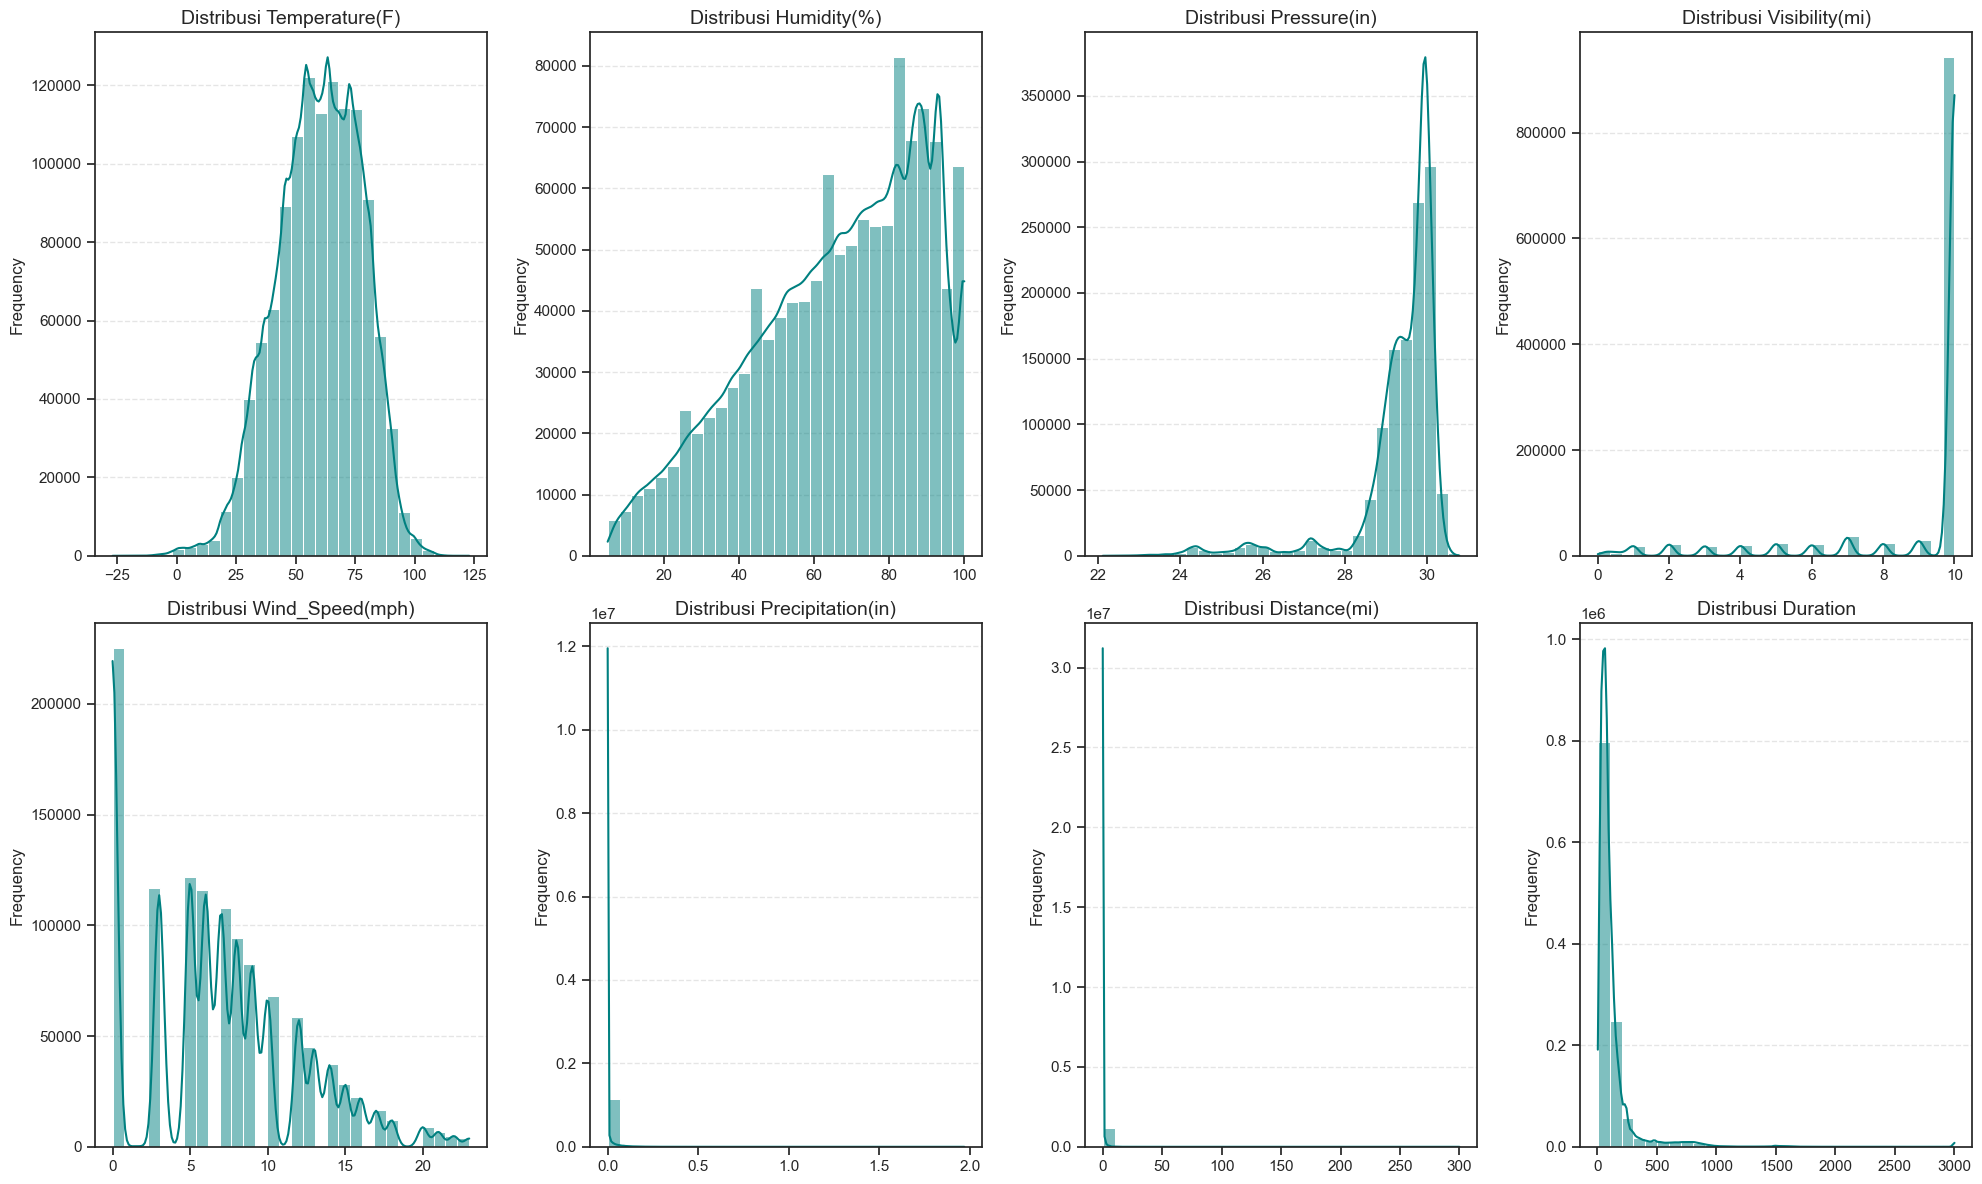

In [55]:
n_cols = 4
n_rows = 2

plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, color="teal", bins=30)
    
    plt.title(f"Distribusi {col}", fontsize=14)
    plt.xlabel("")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# EDA 
Dilakukan setelah semua data rapi dan bagus

## State dengan Jumlah Terbanyak

In [56]:
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Total_Accidents']

fig = px.choropleth(state_counts, 
                    locations='State', 
                    locationmode="USA-states", 
                    color='Total_Accidents',
                    scope="usa",
                    color_continuous_scale="Reds",
                    title='Total Kecelakaan Lalu Lintas per Negara Bagian (USA)')

fig.show()

In [57]:
df.State.value_counts()

State
CA    285532
FL    130362
TX     73488
SC     62789
NY     48805
NC     48633
VA     44803
PA     43189
MN     39193
OR     34452
AZ     29535
TN     28463
LA     26342
IL     25007
MD     24351
GA     23427
AL     20185
NJ     18590
OH     17240
UT     16192
MI     15763
CO     13889
OK     13590
WA     13211
MA     11101
MO     10372
CT      9341
IN      7806
KY      5568
WI      3933
IA      3649
AR      3090
KS      2644
DC      2632
NE      2493
DE      2478
MT      2450
NV      2442
RI      2387
ID      2319
MS      2019
NH      1496
NM      1436
WV      1171
ND       399
ME       281
VT       186
SD       160
WY        29
Name: count, dtype: int64

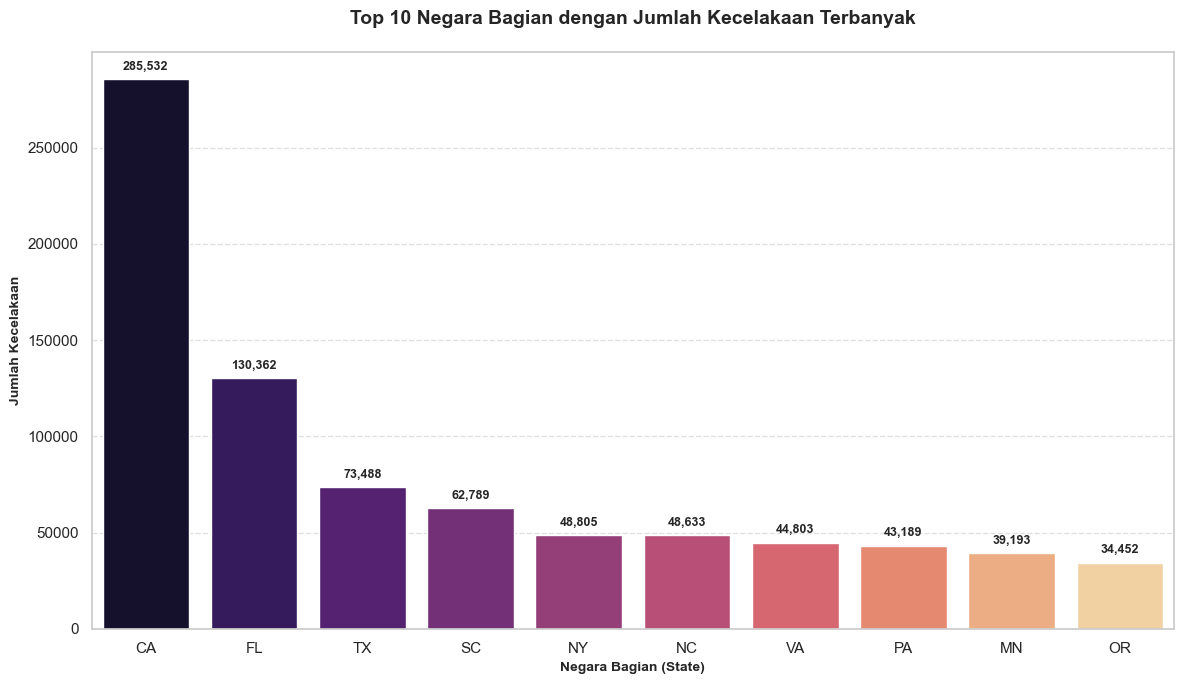

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan Data
data = {
    'State': ['CA', 'FL', 'TX', 'SC', 'NY', 'NC', 'VA', 'PA', 'MN', 'OR'],
    'Jumlah Kecelakaan': [285532, 130362, 73488, 62789, 48805, 48633, 44803, 43189, 39193, 34452]
}
df = pd.DataFrame(data)

# 2. Mengatur Style Visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 3. Membuat Barplot dengan palette 'magma'
# Catatan: Kita gunakan palette 'magma' dengan jumlah n sesuai baris data
ax = sns.barplot(
    x='State', 
    y='Jumlah Kecelakaan', 
    data=df, 
    palette='magma',
    hue='State', # Memberikan warna per kategori
    legend=False
)

# 4. Menambahkan Label Angka di Atas Bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9,
                fontweight='bold')

# 5. Kostumisasi Label dan Judul
plt.title('Top 10 Negara Bagian dengan Jumlah Kecelakaan Terbanyak', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Negara Bagian (State)', fontsize=10, fontweight='bold')
plt.ylabel('Jumlah Kecelakaan', fontsize=10, fontweight='bold')

# Mengatur grid agar hanya muncul secara horizontal (garis putus-putus)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.xaxis.grid(False)

# Menyesuaikan layout agar tidak terpotong
plt.tight_layout()

# Tampilkan Grafik
plt.show()

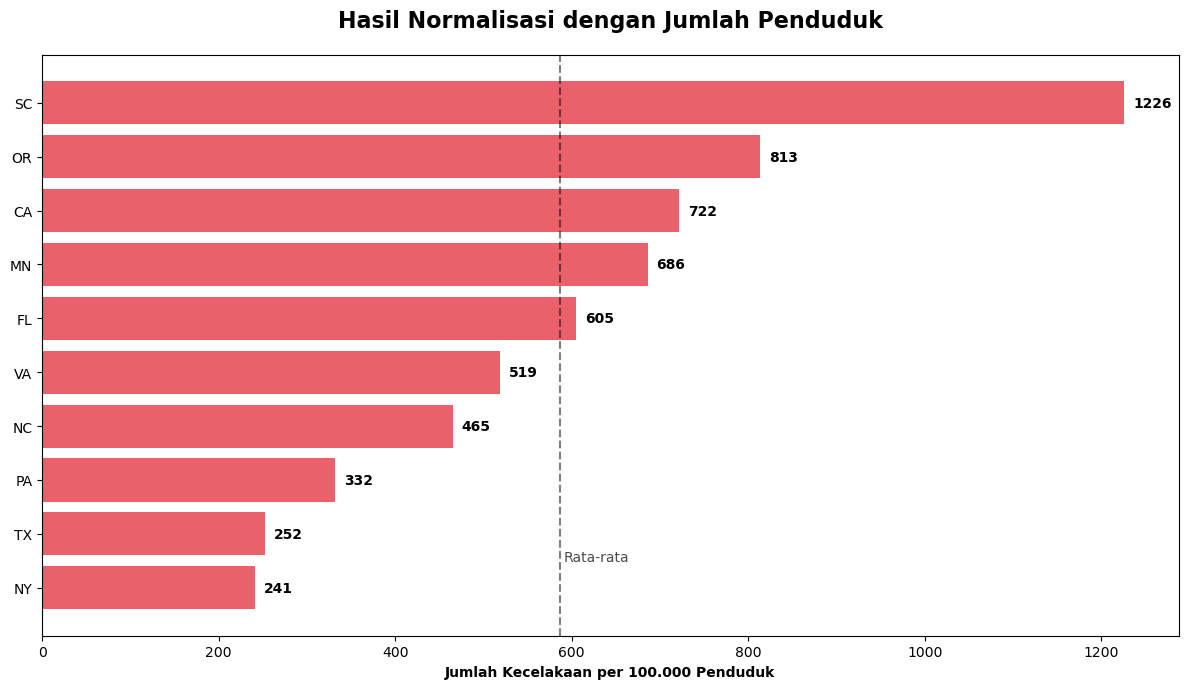

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Data yang telah disiapkan
data = {
    'State': ['SC', 'OR', 'MN', 'CA', 'FL', 'VA', 'NC', 'PA', 'TX', 'NY'],
    'Total Kecelakaan': [62789, 34452, 39193, 285532, 130362, 44803, 48633, 43189, 73488, 48805],
    'Per 100k Penduduk': [1226, 813, 686, 722, 605, 519, 465, 332, 252, 241]
}

df = pd.DataFrame(data).sort_values('Per 100k Penduduk', ascending=True)

fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar Chart untuk Rasio (Fokus Utama)
color_ratio = '#e63946' # Merah untuk risiko
bars = ax1.barh(df['State'], df['Per 100k Penduduk'], color=color_ratio, alpha=0.8, label='Kecelakaan per 100k Penduduk')
ax1.set_xlabel('Jumlah Kecelakaan per 100.000 Penduduk', fontweight='bold')
ax1.set_title('Hasil Normalisasi dengan Jumlah Penduduk', fontsize=16, pad=20, fontweight='bold')

# Tambahkan label angka di ujung bar
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 10, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', fontweight='bold')

# Tambahkan garis vertikal rata-rata untuk konteks pitching
plt.axvline(df['Per 100k Penduduk'].mean(), color='black', linestyle='--', alpha=0.5)
plt.text(df['Per 100k Penduduk'].mean()+5, 0.5, 'Rata-rata', alpha=0.7)

plt.tight_layout()
plt.show()

## State dengan Severity Tertinggi

In [58]:
# Cari tau state dengan rata2 severity tertinggi 
state_severity = df.groupby('State')['Severity'].mean().reset_index()

state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Accident_Count']

map_data = pd.merge(state_severity, state_counts, on='State')

print(map_data.sort_values(by='Severity', ascending=False).head())

   State  Severity  Accident_Count
48    WY  3.275862              29
12    IL  2.611909           25007
46    WI  2.575896            3933
13    IN  2.545478            7806
22    MO  2.528153           10372


In [59]:
fig = px.choropleth(
    map_data, 
    locations='State',            
    locationmode="USA-states",    
    color='Severity',             
    hover_name='State',           
    hover_data=['Accident_Count'],
    color_continuous_scale="Reds",
    scope="usa",                  
    title='Rata-rata Severity Kecelakaan per Negara Bagian'
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

## Kota dengan Severity Tinggi

In [10]:
# Cari tau city dengan rata2 severity tertinggi 
city_severity = df.groupby('City')['Severity'].mean().reset_index()

city_counts = df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Accident_Count']

map_data = pd.merge(city_severity, city_counts, on='City')

print(map_data.sort_values(by='Severity', ascending=False).head(20))

               City  Severity  Accident_Count
9540        Zwingle       4.0               3
5346         Mexico       4.0               2
5630   Mount Bethel       4.0               6
5632  Mount Carroll       4.0               1
5633    Mount Clare       4.0               1
3943   Hurdle Mills       4.0               1
3920       Huguenot       4.0               6
3887      Hotchkiss       4.0               2
2909   Fort Bridger       4.0               1
3880    Hortonville       4.0               5
5684   Mountainburg       4.0               1
3873       Horntown       4.0               1
3841          Hondo       4.0               1
3837       Hometown       4.0               1
3827         Holton       4.0               2
8048   Spring Arbor       4.0               1
6574       Penn Yan       4.0               2
2355    East Canaan       4.0               8
173         Anahuac       4.0               1
835         Botkins       4.0               1


In [14]:
# 1. Filter data awal: hanya ambil baris dengan Severity 4
df_sev4 = df[df['Severity'] == 4]

# 2. Hitung jumlah kecelakaan per kota untuk Severity 4 tersebut
city_counts = df_sev4['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Accident_Count']

# 3. Hitung rata-rata Severity (opsional, karena semua sudah Severity 4, hasilnya pasti 4.0)
city_severity = df_sev4.groupby('City')['Severity'].mean().reset_index()

# 4. Gabungkan data
map_data = pd.merge(city_severity, city_counts, on='City')

# 5. Filter hanya yang jumlah kecelakaannya lebih dari 6
map_data_filtered = map_data[map_data['Accident_Count'] > 6]

# 6. Tampilkan hasil urut dari jumlah terbanyak
print(map_data_filtered.sort_values(by='Accident_Count', ascending=False))

                 City  Severity  Accident_Count
160           Atlanta       4.0             528
2462            Miami       4.0             393
919            Dallas       4.0             382
4061       Washington       4.0             312
831           Corbett       4.0             246
...               ...       ...             ...
3872         Torrance       4.0               7
1871        Inglewood       4.0               7
3126     Port Reading       4.0               7
1897           Ithaca       4.0               7
2541  Montgomeryville       4.0               7

[1042 rows x 3 columns]


## Distribusi Kecelakaan berdasarkan Waktu

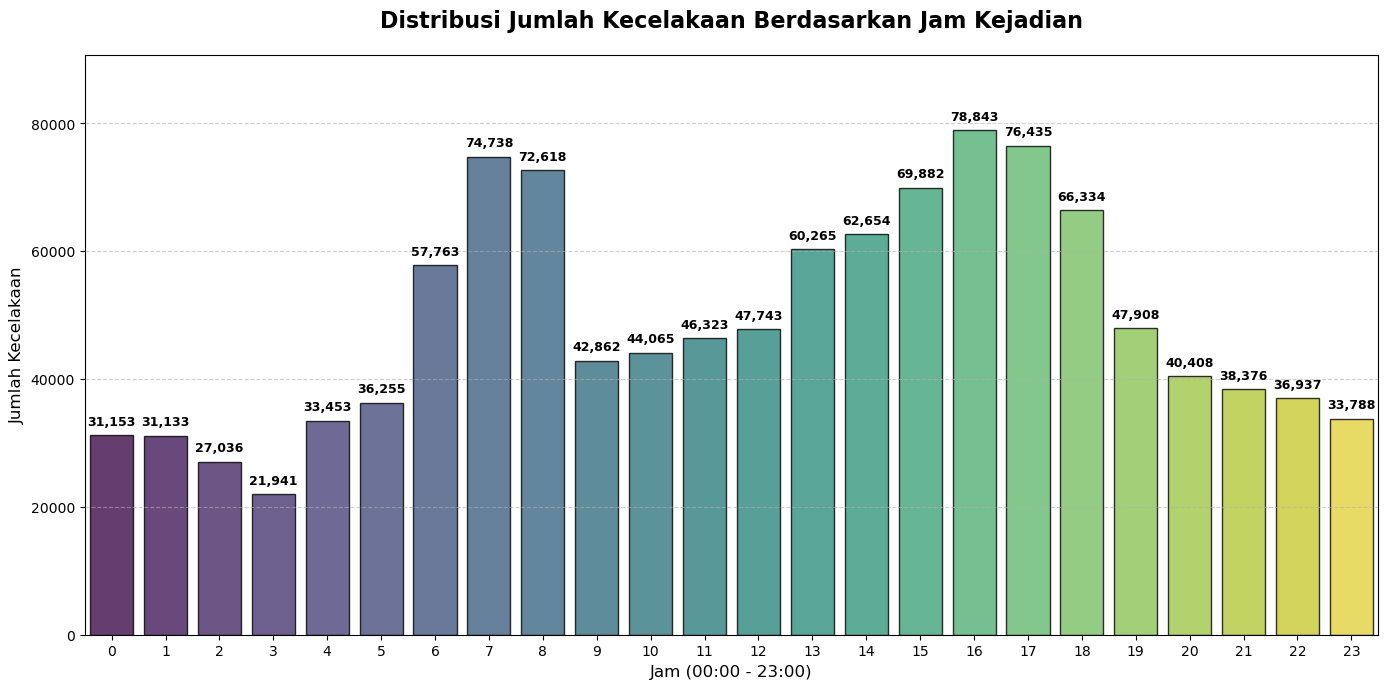

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribusi Kecelakaan berdasarkan Waktu
plt.figure(figsize=(14, 7))

# 1. Membuat plot (menggunakan hue=x agar bisa menggunakan palette viridis)
ax = sns.countplot(data=df, x="Hour", hue="Hour", palette="viridis", legend=False, edgecolor="black", alpha=0.8)

# 2. Menambahkan label jumlah (angka) di atas setiap bar
for p in ax.patches:
    # Mendapatkan tinggi batang (jumlah kecelakaan)
    height = p.get_height()
    if height > 0: # Pastikan hanya menulis jika ada datanya
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 10), 
                    textcoords = 'offset points',
                    fontsize=9,
                    fontweight='bold',
                    rotation=0)

# 3. Estetika Grafik
plt.title("Distribusi Jumlah Kecelakaan Berdasarkan Jam Kejadian", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Jam (00:00 - 23:00)", fontsize=12)
plt.ylabel("Jumlah Kecelakaan", fontsize=12)

# Mengatur agar sumbu Y memiliki ruang lebih untuk label angka
plt.ylim(0, df['Hour'].value_counts().max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Distribusi Kecelakaan Berdasarkan Weekday dan Weekend

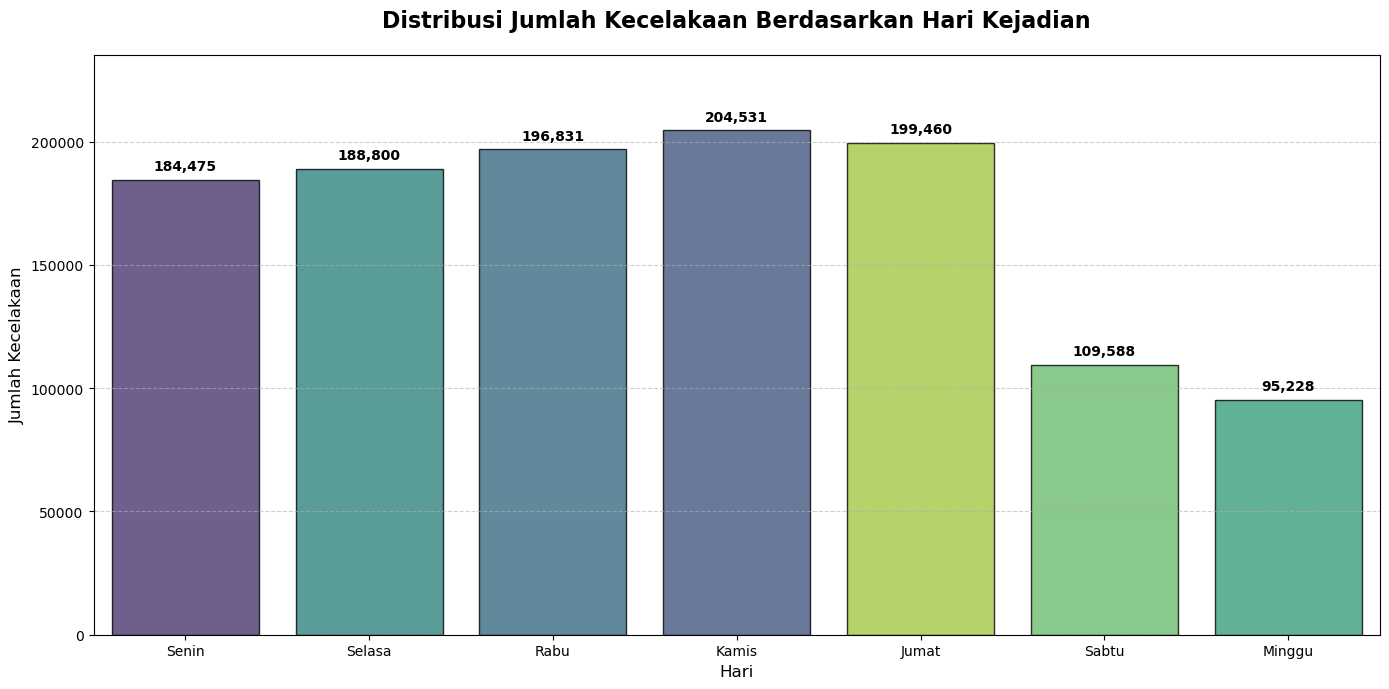

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mapping Angka ke Nama Hari (Asumsi 0 = Senin, standar Pandas)
day_map = {0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4: 'Jumat', 5: 'Sabtu', 6: 'Minggu'}

# Buat kolom baru atau timpa kolom Day dengan nama harinya
# Kita gunakan urutan (order) agar grafiknya tetap berurutan dari Senin ke Minggu
day_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
df['Day_Name'] = df['Day'].map(day_map)

# Distribusi Kecelakaan berdasarkan Hari
plt.figure(figsize=(14, 7))

# 2. Membuat plot dengan order yang ditentukan
ax = sns.countplot(
    data=df, 
    x="Day_Name", 
    order=day_order, 
    hue="Day_Name", 
    palette="viridis", 
    legend=False, 
    edgecolor="black", 
    alpha=0.8
)

# 3. Menambahkan label jumlah (angka) di atas setiap bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 10), 
                    textcoords = 'offset points',
                    fontsize=10,
                    fontweight='bold')

# 4. Estetika Grafik
plt.title("Distribusi Jumlah Kecelakaan Berdasarkan Hari Kejadian", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hari", fontsize=12)
plt.ylabel("Jumlah Kecelakaan", fontsize=12)

# Mengatur batas Y agar label angka tidak terpotong
plt.ylim(0, df['Day_Name'].value_counts().max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

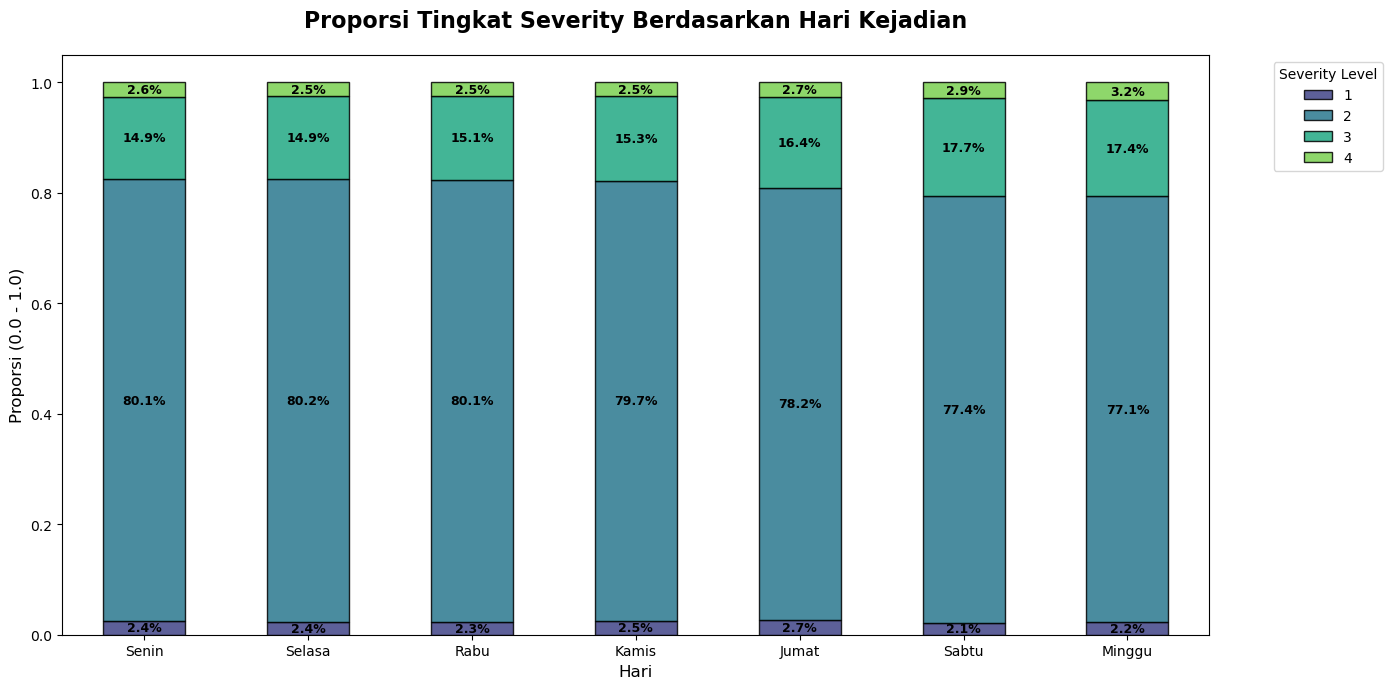

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menyiapkan Data: Grouping berdasarkan Hari dan Severity
# Pastikan 'Day' sudah di-mapping ke nama hari atau gunakan urutan yang benar
day_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
if 'Day_Name' not in df.columns:
    day_map = {0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4: 'Jumat', 5: 'Sabtu', 6: 'Minggu'}
    df['Day_Name'] = df['Day'].map(day_map)

# Membuat tabel silang (cross-tabulation) antara Hari dan Severity
ct = pd.crosstab(df['Day_Name'], df['Severity'])

# Reindex agar urutan hari sesuai (Senin -> Minggu)
ct = ct.reindex(day_order)

# Normalisasi menjadi proporsi (0.0 - 1.0) untuk stacked bar 100%
ct_prop = ct.div(ct.sum(1), axis=0)

# 2. Plotting
plt.figure(figsize=(14, 8))
ax = ct_prop.plot(kind='bar', stacked=True, figsize=(14, 7), 
                  color=sns.color_palette("viridis", n_colors=4), 
                  edgecolor='black', alpha=0.85)

# 3. Menambahkan Label Persentase di dalam Bar
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0.02: # Hanya tampilkan label jika proporsinya cukup besar (>2%)
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                fontsize=9,
                fontweight='bold',
                color='black') # Kontras warna teks

# 4. Estetika Grafik
plt.title("Proporsi Tingkat Severity Berdasarkan Hari Kejadian", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hari", fontsize=12)
plt.ylabel("Proporsi (0.0 - 1.0)", fontsize=12)
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Distribusi Kecelakaan berdasarkan Weather_Condition

C:\Users\claire\AppData\Local\Temp\ipykernel_6452\2063745407.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




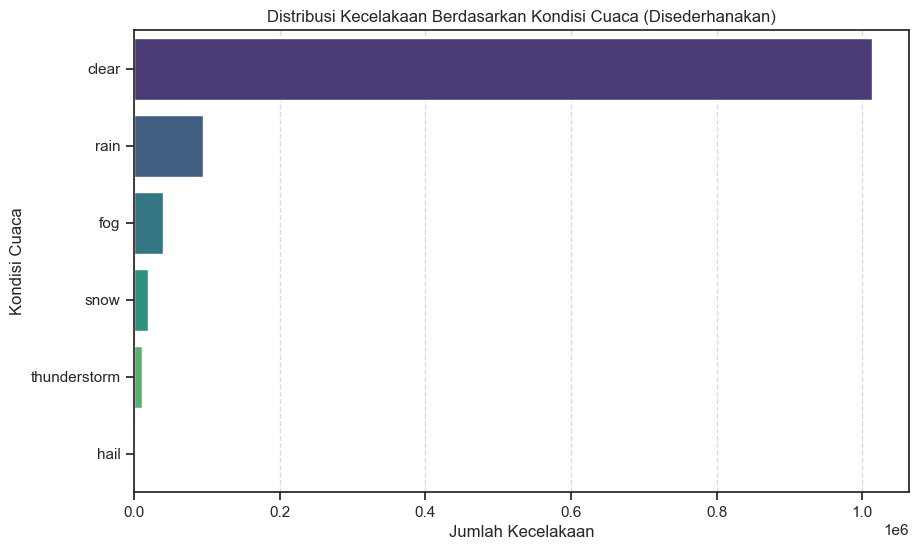

In [61]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Weather_Condition', order=df['Weather_Condition'].value_counts().index, palette='viridis')
plt.title('Distribusi Kecelakaan Berdasarkan Kondisi Cuaca (Disederhanakan)')
plt.xlabel('Jumlah Kecelakaan')
plt.ylabel('Kondisi Cuaca')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

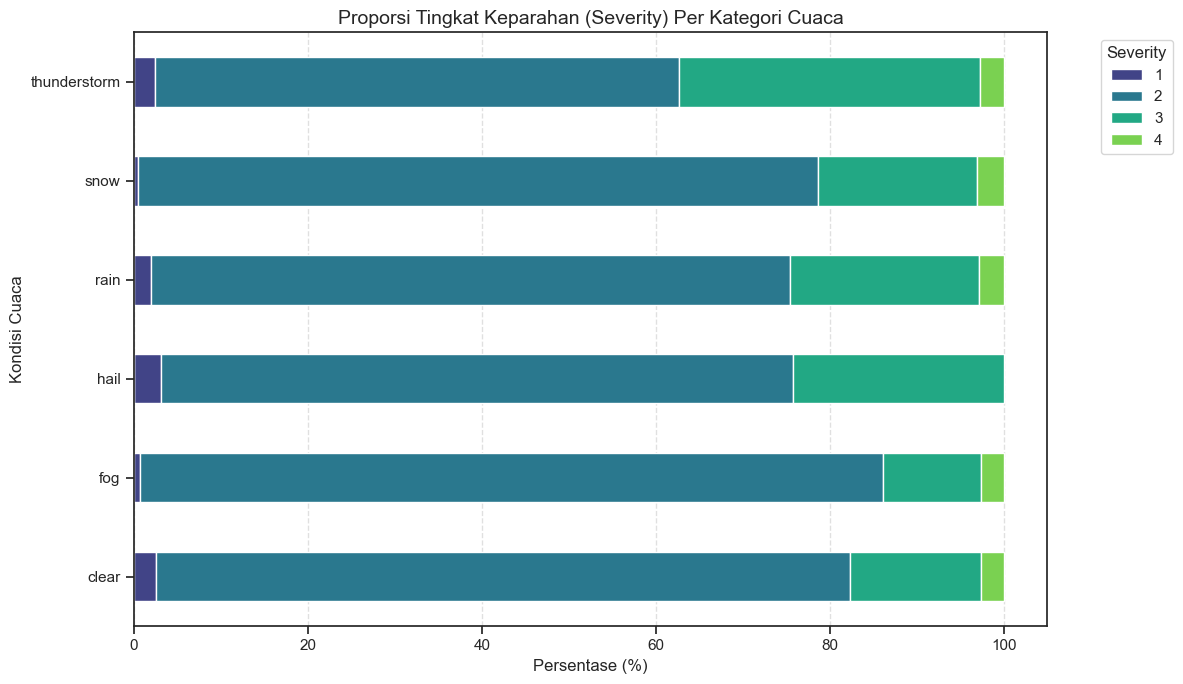

In [62]:
weather_severity_cross = pd.crosstab(df['Weather_Condition'], df['Severity'])

weather_severity_pct = weather_severity_cross.div(weather_severity_cross.sum(1), axis=0) * 100

weather_severity_pct.plot(kind='barh', stacked=True, figsize=(12, 7), 
                          color=sns.color_palette("viridis", 4))

plt.title('Proporsi Tingkat Keparahan (Severity) Per Kategori Cuaca', fontsize=14)
plt.xlabel('Persentase (%)')
plt.ylabel('Kondisi Cuaca')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

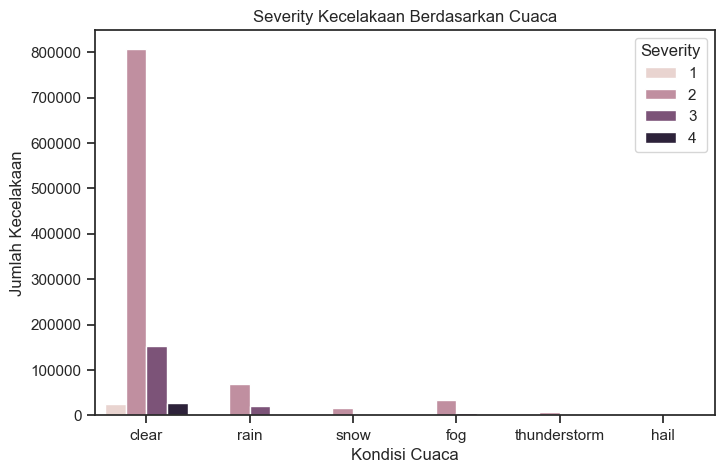

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Weather_Condition", hue="Severity")

plt.title("Severity Kecelakaan Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Kecelakaan")

plt.show()

## Distribusi Kecelakaan tiap Bulan

C:\Users\claire\AppData\Local\Temp\ipykernel_6452\4283050729.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




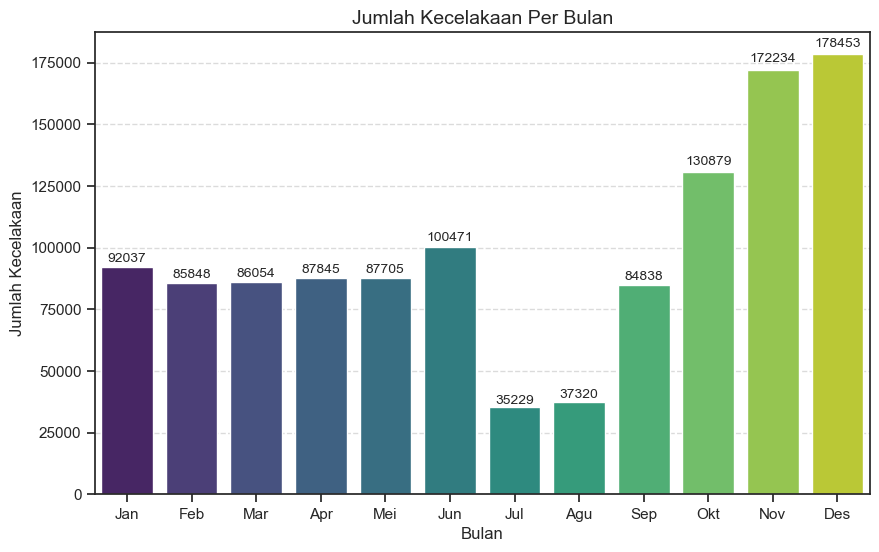

In [64]:
# Distribusi per Bulan
monthly_counts = df['Month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
plt.figure(figsize=(10, 6))
sns.barplot(x=month_names, y=monthly_counts.values, palette='viridis')

plt.title('Jumlah Kecelakaan Per Bulan', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Kecelakaan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(monthly_counts.values):
    plt.text(i, val + (val*0.01), f'{int(val)}', ha='center', va='bottom', fontsize=10)

plt.show()

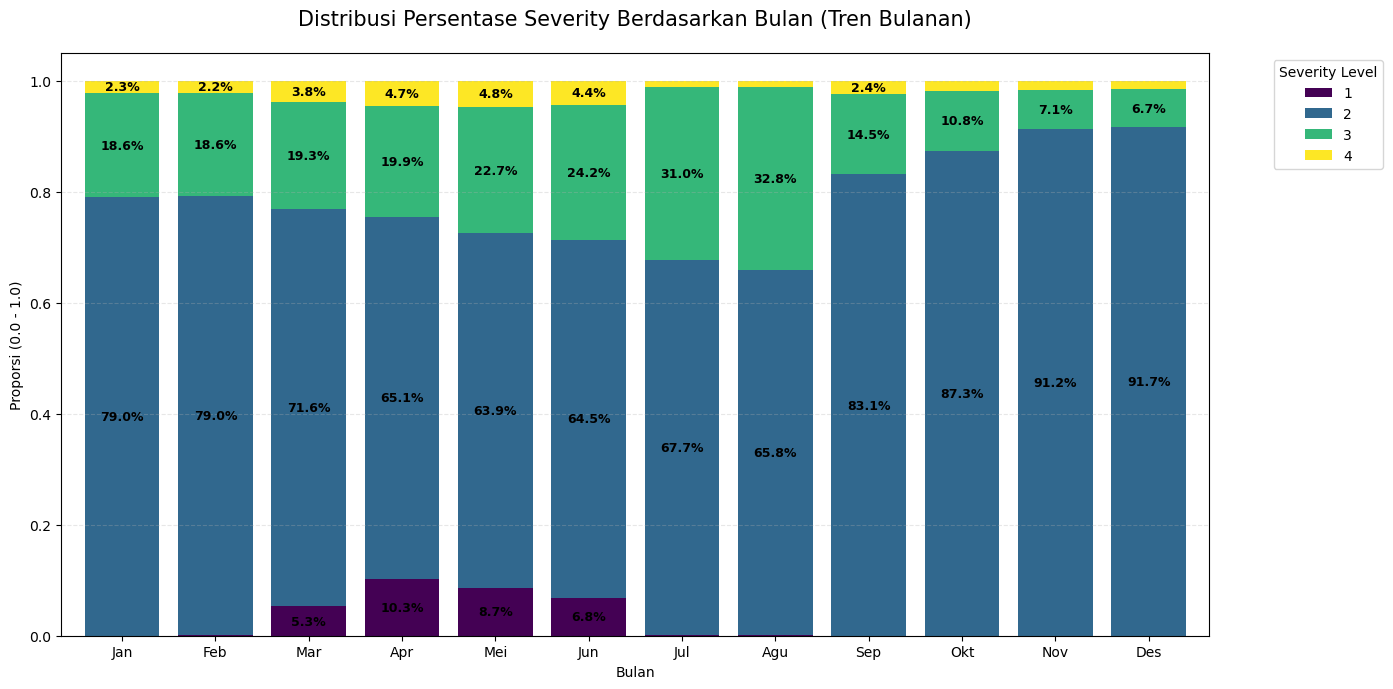

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pastikan kolom 'Month' ada. Jika belum, ekstrak dari kolom waktu (contoh: Start_Time)
# df['Month'] = pd.to_datetime(df['Start_Time']).dt.month

# 2. Buat crosstab antara Month dan Severity
# normalize='index' digunakan untuk melihat proporsi tingkat keparahan tiap bulannya
cross_tab_month = pd.crosstab(df['Month'], df['Severity'], normalize='index')

# 3. Urutkan berdasarkan bulan (1 sampai 12) agar trennya terlihat kronologis
cross_tab_month = cross_tab_month.sort_index()

# 4. Plotting
# Menggunakan stacked bar untuk melihat komposisi severity tiap bulan
ax = cross_tab_month.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis', width=0.8)

# 5. Tambahkan label persentase di dalam batang
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0.02: # Tampilkan label jika proporsi di atas 2% agar tidak berantakan
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='black', 
                fontsize=9,
                fontweight='bold')

# 6. Estetika Grafik
plt.title("Distribusi Persentase Severity Berdasarkan Bulan (Tren Bulanan)", fontsize=15, pad=20)
plt.ylabel("Proporsi (0.0 - 1.0)")
plt.xlabel("Bulan")

# Mengganti angka 1-12 menjadi nama bulan agar lebih mudah dibaca
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
plt.xticks(ticks=range(12), labels=month_names[:len(cross_tab_month)], rotation=0)

plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

## Hubungan Road_Features dengan Severity

C:\Users\claire\AppData\Local\Temp\ipykernel_6452\2586179066.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




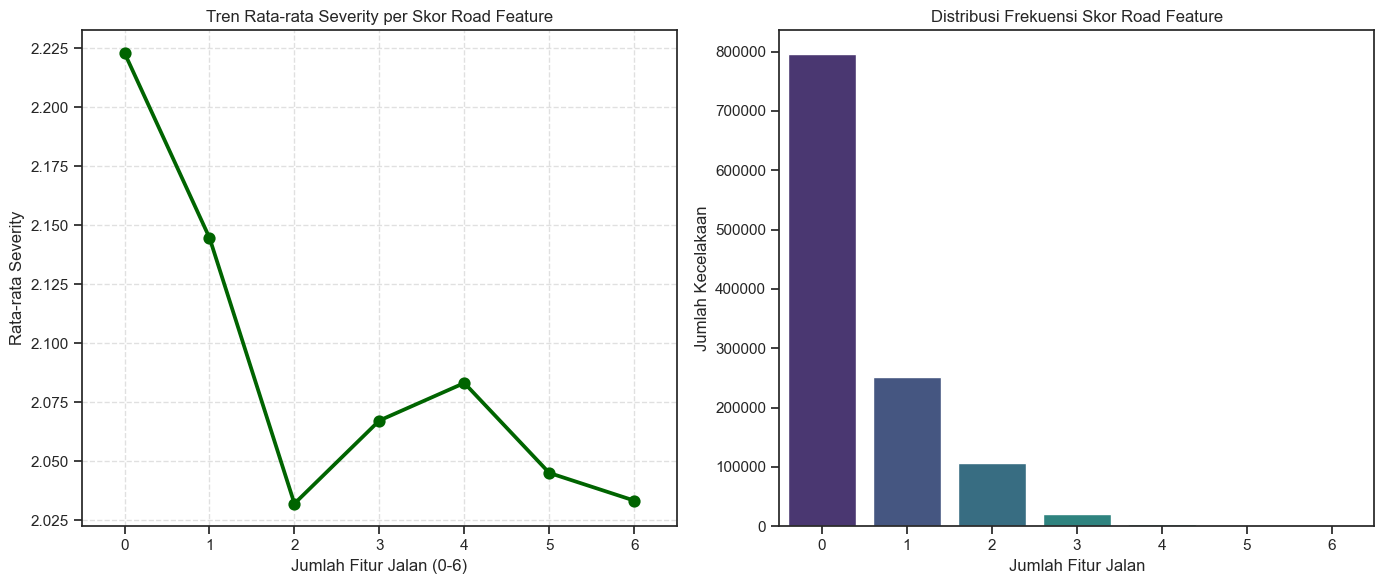

In [65]:
# Hubungan road_features dengan severity
road_impact = df.groupby('Road_Features')['Severity'].mean().reset_index()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.pointplot(data=road_impact, x='Road_Features', y='Severity', color='darkgreen')
plt.title('Tren Rata-rata Severity per Skor Road Feature')
plt.xlabel('Jumlah Fitur Jalan (0-6)')
plt.ylabel('Rata-rata Severity')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Road_Features', palette='viridis')
plt.title('Distribusi Frekuensi Skor Road Feature')
plt.xlabel('Jumlah Fitur Jalan')
plt.ylabel('Jumlah Kecelakaan')

plt.tight_layout()
plt.show()

C:\Users\claire\AppData\Local\Temp\ipykernel_11164\3211666512.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Road_Features', palette='viridis')


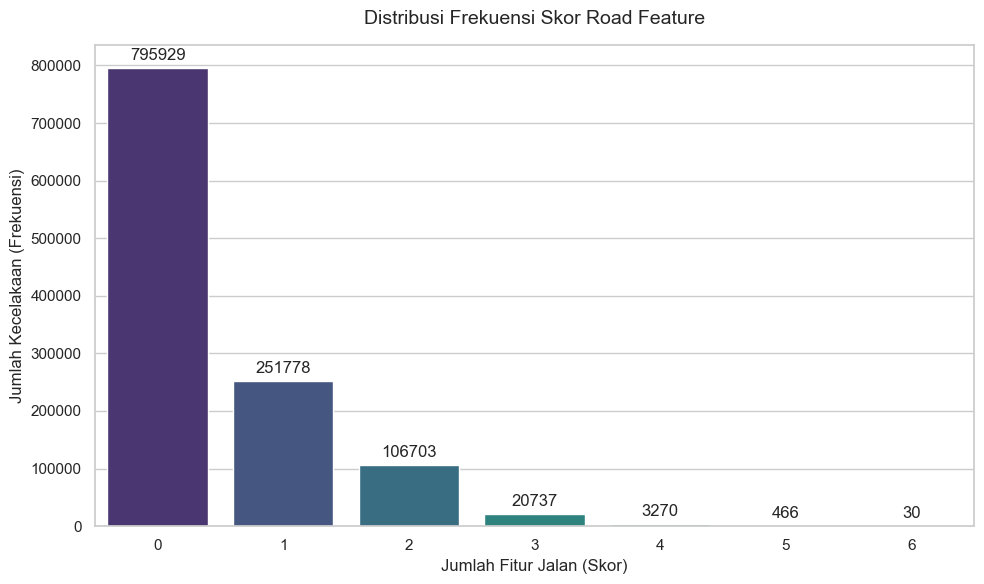

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan df sudah terdefinisi sebelumnya
plt.figure(figsize=(10, 6))

# Membuat grafik distribusi frekuensi saja
sns.countplot(data=df, x='Road_Features', palette='viridis')

# Menambahkan detail keterangan
plt.title('Distribusi Frekuensi Skor Road Feature', fontsize=14, pad=15)
plt.xlabel('Jumlah Fitur Jalan', fontsize=12)
plt.ylabel('Jumlah Kecelakaan (Frekuensi)', fontsize=12)

# Opsional: Menambahkan label jumlah di atas bar untuk presisi data
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

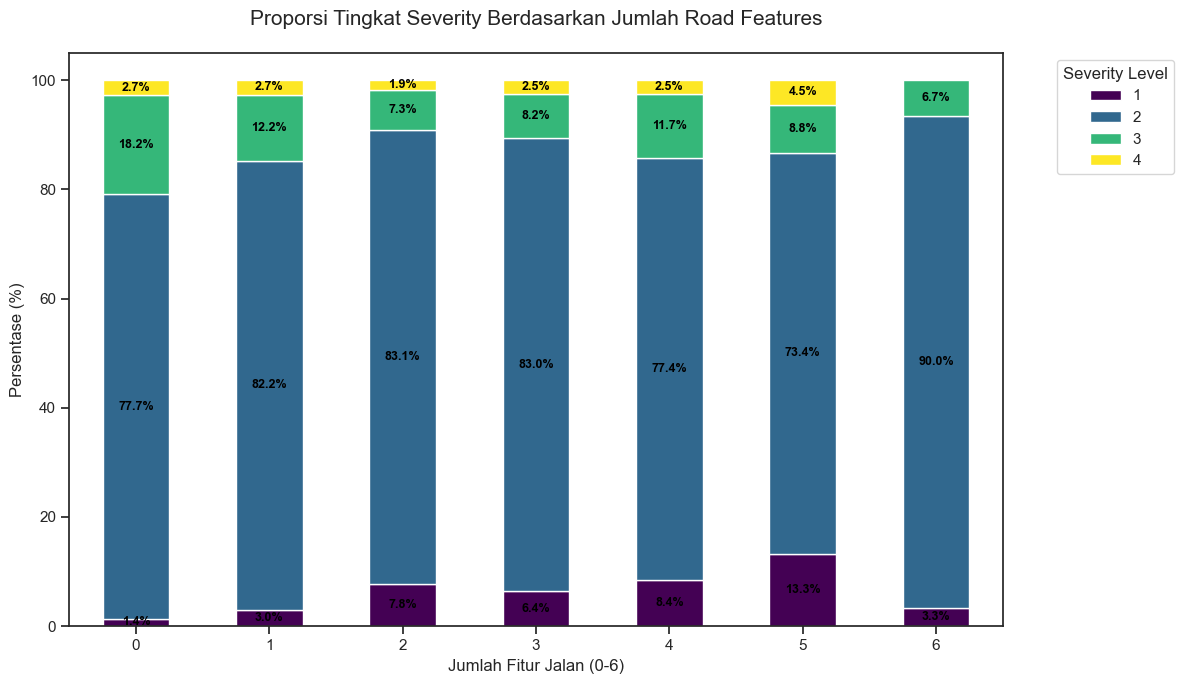

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Membuat tabel kontingensi (proporsi)
# Normalize='index' akan mengubah jumlah mentah menjadi persentase per baris
proporsi_severity = pd.crosstab(df['Road_Features'], df['Severity'], normalize='index') * 100

# 2. Visualisasi Stacked Bar Chart
ax = proporsi_severity.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

# 3. Menambahkan Detail Label
plt.title('Proporsi Tingkat Severity Berdasarkan Jumlah Road Features', fontsize=15, pad=20)
plt.xlabel('Jumlah Fitur Jalan (0-6)', fontsize=12)
plt.ylabel('Persentase (%)', fontsize=12)
plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# 4. Opsional: Menambahkan label persentase di dalam bar
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: # Hanya tampilkan jika persentase > 0
        x, y = p.get_xy() 
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# Hasil Akhir

In [66]:
df.shape

(1178913, 33)

In [67]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Astronomical_Twilight',
       'Duration', 'Hour', 'Month', 'Day', 'Road_Features'],
      dtype='object')

# Simpan Dataset

In [68]:
df.to_csv('US_Accidents_Cleaned.csv', index=False)

In [72]:
df['Humidity(%)'].unique()

array([ 74.  ,  81.  ,  91.  ,  72.  ,  69.  ,  41.  ,  89.  ,  93.  ,
        80.  ,  57.  ,  68.  ,  78.  ,  64.  ,  67.  ,  54.  ,  82.  ,
        92.  ,  86.  ,  85.  , 100.  ,  79.  ,  76.  ,  75.  ,  73.  ,
        48.  ,  53.  ,  51.  ,  65.  ,  50.  ,  55.  ,  61.  ,  56.  ,
        96.  ,  60.  ,  59.  ,  87.  ,  70.  ,  58.  ,  52.  ,  83.  ,
        97.  ,  88.  ,  77.  ,  63.  ,  71.  ,  62.  ,  90.  ,  66.  ,
        76.5 ,  86.5 ,  84.  ,  95.  ,  94.  ,  99.  ,  78.5 ,  98.  ,
        47.  ,  35.  ,  26.  ,  28.  ,  37.  ,  44.  ,  42.5 ,  39.  ,
        34.  ,  14.  ,  21.  ,  46.  ,  29.  ,  42.  ,  38.  ,  33.  ,
        30.  ,  19.  ,  20.  ,  24.  ,  15.  ,  25.  ,  17.  ,  27.  ,
        23.  ,  45.  ,  40.  ,  49.  ,  81.5 ,  31.  ,  43.  ,  32.  ,
        36.  ,  22.  ,  13.  ,  11.  ,  10.  ,  12.  ,  16.  ,  18.  ,
         8.  ,  84.5 ,  67.5 ,  61.5 ,   6.  ,   7.  ,   9.  ,  17.5 ,
        70.5 ,   5.  ,  79.5 ,  93.5 ,  71.5 ,  62.5 ,  54.5 ,  77.5 ,
      